# DP10 - Anouck Jansen

| | |
|---|---|
| **Opdrachtgever** | Isala Ziekenhuis Zwolle |
| **Data Scientist** | Anouck Jansen |
| **Dataset** | Sepsis ICU dataset - Isala / Windesheim |
| **Opleverdatum** | 08-06-2026 |


**Leertaken:**
* **AD1**           - Evaluation
* **MC1**           - Data mining
* **AD3**           - Ethiek & Maatschappij

## **AN1 - Business understanding**

### Businessvraag

#### Hoofdvraag
> Kunnen we op basis van klinische meetwaarden (vitale parameters, laboratoriumwaarden en demografische data) vroegtijdig voorspellen of een IC-patiënt sepsis zal ontwikkelen?

#### Sub-doel: Fairness
Als onderdeel van de evaluatie wordt onderzocht in hoeverre het model gelijk presteert voor verschillende patiëntgroepen (leeftijd en geslacht), en wat de ethische implicaties zijn van eventuele prestatieverschillen.

### Aanleiding:

Sepsis is een levensbedreigende aandoening waarbij het lichaam overmatig reageert op een infectie, wat kan leiden tot orgaanfalen en overlijden. Jaarlijks overlijden wereldwijd meer dan 11 miljoen mensen aan sepsis. In Nederland worden jaarlijks tienduizenden patiënten opgenomen met sepsis, waarvan een significant deel op de Intensive Care (IC). Vroegtijdige herkenning en behandeling is de sleutel tot overleving: elke vertraging van één uur in de behandeling verhoogt de sterfte significant.

Het Isala ziekenhuis in Zwolle heeft als één van de grotere perifere ziekenhuizen van Nederland een drukbezette IC-afdeling. Verpleegkundigen en artsen monitoren continu tientallen vitale parameters en laboratoriumwaarden per patiënt. Het handmatig herkennen van vroegtijdige sepsissignalen in al deze data is een uitdagende taak, zeker bij hoge werkdruk.

Een voorspellend model dat automatisch en continu de kans op sepsis berekent op basis van beschikbare meetwaarden, kan het klinische personeel ondersteunen om eerder in te grijpen. Dit kan levens redden en ziekenhuisopnames verkorten.

### Datavraag
> Kan een classificatiemodel, getraind op klinische features (vitale parameters en laboratoriumwaarden) per uur, voorspellen of een patiënt in de komende uren sepsis ontwikkelt (SepsisLabel = 1)?

### Organisatorische context

Dit onderzoek wordt uitgevoerd in het kader van de differentiatieopdracht Data Science voor Hogeschool Windesheim, in samenwerking met het Isala Ziekenhuis te Zwolle. Het Isala is een topklinisch opleidingsziekenhuis met een grote IC-afdeling. Het model is bedoeld als decision support tool voor IC-verpleegkundigen en -artsen: het signaleert risicovolle patiënten, waarna de behandelaar zelf de beslissing neemt.

### Maatschappelijke context

* **Patiëntveiligheid:** Sepsis heeft een hoge mortaliteit. Een eerder en betrouwbaarder signaleringsmodel kan directe levensreddende impact hebben voor IC-patiënten.
* **Werkdruk zorgpersoneel:** IC-personeel opereert onder hoge werkdruk. Een AI-ondersteund vroegwaarschuwingssysteem kan prioritering in zorgverlening ondersteunen zonder het klinisch oordeel te vervangen.
* **Fairness:** Het model wordt getraind op data van patiënten met wisselende leeftijden en geslachten. Als het model systematisch slechter presteert voor bepaalde groepen (bijvoorbeeld oudere patiënten of vrouwen), kan dit leiden tot ongelijke zorg. Dit wordt expliciet geanalyseerd als sub-doel van dit onderzoek.
* **Privacy:** De gebruikte dataset bevat geanonimiseerde medische gegevens. In een echte ziekenhuisomgeving zijn medische gegevens bijzondere persoonsgegevens (AVG Artikel 9) en vereist verwerking een expliciete juridische grondslag.
* **Automation bias:** Er bestaat een risico dat zorgverleners te veel vertrouwen op de modeluitkomst en hun eigen klinisch oordeel minder inzetten. Het model dient uitdrukkelijk als ondersteuning, niet als vervanging.
* **Klasse-onbalans:** Slechts ~1,8% van de observaties in de dataset heeft een sepsislabel. Een model dat altijd 0 voorspelt behaalt al 98,2% accuracy, wat misleidend is. Dit vraagt om specifieke evaluatiemetrics.
* **Invloed op detectie:** Wanneer het model betrouwbaar genoeg lijkt en ingezet wordt, kan dit een negatieve invloed hebben op het klinisch oordeel van artsen en verpleegkundigen. Het model is bedoeld als ondersteuning bij het signaleren van sepsis, maar het risico bestaat dat zorgverleners steeds meer leunen op de modeluitkomst en hun eigen observaties minder zwaar laten wegen.

### Juridische implicaties
Voor dit onderzoek is kritisch gekeken naar de juridische kaders rondom databescherming — Algemene verordernig gegevensbescherming (AVG) en de AI act. Hieruit komen de volgende bevindingen naar voren.

* **AVG Artikel 9**\
    **Bijzondere persoonsgegevens:** In Artikel 9 van de EU-AVG "Verwerking van bijzondere categorieën van persoonsgegevens" wordt het verwerken van medische gegevens benoemd. Gegevens over gezondheid en fysiologische toestand vallen onder dit artikel. De AVG stelt dat verwerking van dergelijke gegevens in principe verboden is, tenzij aan strikte voorwaarden is voldaan — zoals expliciete toestemming of verwerking ten behoeve van wetenschappelijk onderzoek met adequate waarborgen.

    **Geanonimiseerde dataset:** De gebruikte MIMIC-III dataset is voor dit onderzoek geanonimiseerd. Patiëntidentificerende informatie is verwijderd, waardoor de data buiten de directe werking van de AVG valt. Er is geen mogelijkheid om op basis van de beschikbare data de identiteit van individuele patiënten te achterhalen.

    **Conclusie**\
    Aangezien de dataset volledig geanonimiseerd is, is de AVG niet van toepassing op dit onderzoek. Tijdens de ontwikkeling van het model is er geen sprake van een privacyrisico. Desalniettemin geldt dat bij daadwerkelijke ziekenhuisinzet — waarbij het model wordt gekoppeld aan real-time patiëntdata — de AVG onverkort van toepassing is en een expliciete juridische grondslag vereist is.
    [AVG Artikel 9](https://www.privacy-regulation.eu/nl/artikel-9-verwerking-van-bijzondere-categorieen-van-persoonsgegevens-EU-AVG.htm)

* **AI Act**\
    **Annex III (hoog risico):** Volgens de AI Act vallen medische AI-systemen die worden ingezet voor diagnose- of behandelbeslissingen onder de hoog-risicocategorie (Annex III). De AI Act omschrijft dit als: *"AI-systemen die bedoeld zijn om te worden gebruikt als medisch hulpmiddel"* en systemen die invloed hebben op de gezondheid en veiligheid van personen. Bij daadwerkelijke inzet in een ziekenhuis gelden daarom strikte eisen op het gebied van transparantie, robuustheid, menselijk toezicht en documentatie. [Annex III](https://artificialintelligenceact.eu/annex/3/)

    **Artikel 10 (Datakwaliteit en Bias):** De AI Act benadrukt het belang van datakwaliteit en het voorkomen van bias. De klasse-onbalans in de dataset (~1.8% sepsislabels) en de mogelijke onderrepresentatie van bepaalde demografische groepen vormen een risico op systematische bias. Dit wordt in dit onderzoek expliciet geadresseerd via de fairness-analyse, maar vormt een aandachtspunt bij verdere ontwikkeling. [AI Act Artikel 10](https://artificialintelligenceact.eu/article/10/)

    **Gevolgen**\
    Dit model is uitsluitend bedoeld ter ondersteuning van zorgverleners, niet als vervanging van klinisch oordeel. Zolang het model niet wordt ingezet in een productieomgeving, zijn de verplichtingen uit de AI Act nog niet van kracht. Bij eventuele toekomstige inzet dient het model volledig te voldoen aan de hoog-risico vereisten van de AI Act.

### Stakeholders

* **Isala Ziekenhuis Zwolle** – Opdrachtgever
* **IC-verpleegkundigen en intensivisten** – Eindgebruikers van het model
* **IC-patiënten** – Degenen wiens zorg direct beïnvloed wordt
* **Hogeschool Windesheim** – Onderwijsinstelling en begeleidende partij
* **Ethische commissie ziekenhuis** – Toetst inzet van AI in klinische praktijk

### KSF & KPI's

**KSF**  
Ontwikkeling van een model dat vroegtijdig en betrouwbaar sepsis kan signaleren bij IC-patiënten op basis van klinische meetwaarden.

**KPI's**
* Top 3 invloedrijke kenmerken bepalen 
* Een **AUROC ≥ 0.80** behalen
* Een **recall (sensitivity) ≥ 0.70** voor de klasse `SepsisLabel = 1` (sepsis detecteren is kritisch)
* **Precision ≥ 0.30** voor de klasse `SepsisLabel = 1` (te veel fout-positieven belasten het personeel)
* Het verschil in AUROC tussen geslachten en leeftijdsgroepen kleiner dan **0.05** (fairness sub-doel)

### Databron

De gebruikte dataset is afkomstig van de Isala opdracht aangeboden via Hogeschool Windesheim. De dataset bevat per patiënt per uur gemeten klinische parameters gedurende het IC-verblijf. De trainset bevat **1.399.302 observaties** van **36.336 unieke patiënten**. De testset bevat **152.908 observaties** van **4.000 unieke patiënten** (zonder sepsislabel).

Beschikbare features:
* **Vitale parameters:** HR, O2Sat, Temp, SBP, MAP, DBP, Resp, EtCO2
* **Laboratoriumwaarden:** BaseExcess, HCO3, FiO2, pH, PaCO2, SaO2, AST, BUN, Alkalinephos, Calcium, Chloride, Creatinine, Bilirubin_direct, Glucose, Lactate, Magnesium, Phosphate, Potassium, Bilirubin_total, TroponinI, Hct, Hgb, PTT, WBC, Fibrinogen, Platelets
* **Patiëntkenmerken:** Age, Gender, Unit1, Unit2, HospAdmTime, ICULOS
* **Target:** SepsisLabel (0 = geen sepsis, 1 = sepsis)

#### Vital signs
| Kolomnaam | Beschrijving | Eenheid |
|---|---|---|
| HR | Hartslag (Heart Rate) | beats per minute |
| O2Sat | Pulse oximetry | % |
| Temp | Temperature | °C |
| SBP | Systolic BP | mm Hg |
| MAP | Mean arterial pressure | mm Hg |
| DBP | Diastolic BP | mm Hg |
| Resp | Respiration rate | breaths per minute |
| EtCO2 | End tidal carbon dioxide | mm Hg |

#### Laboratory values
| Kolomnaam | Beschrijving | Eenheid |
|---|---|---|
| BaseExcess | Excess bicarbonate | mmol/L |
| HCO3 | Bicarbonate | mmol/L |
| FiO2 | Fraction of inspired oxygen | 0–1 |
| pH | Zuurgraad van het bloed | — |
| PaCO2 | Partial pressure of carbon dioxide from arterial blood | mm Hg |
| SaO2 | Oxygen saturation from arterial blood | % |
| AST | Aspartate transaminas | IU/L |
| BUN | Blood urea nitrogen | mg/dL |
| Alkalinephos | Alkaline phosphatase | IU/L |
| Calcium | Calcium | mg/dL |
| Chloride | Chloride | mmol/L |
| Creatinine | Creatinine | mg/dL |
| Bilirubin_direct | Direct bilirubin | mg/dL |
| Bilirubin_total | Total bilirubin | mg/dL |
| Glucose | Serum glucos | mg/dL |
| Lactate | Lactic acid | mmol/L |
| Magnesium | Magnesium | mmol/L |
| Phosphate | Phosphate | mg/dL |
| Potassium | Potassiam | mmol/L |
| TroponinI | Troponin  | ng/mL |
| Hct | Hematocrit  | % |
| Hgb | Hemoglobin  | g/dL |
| PTT | Partial thromboplastin time  | seconds |
| WBC | Leukocyte coun | count/L |
| Fibrinogen | Fibrinogen concentration | mg/dL |
| Platelets | Platelet count | count/mL |

#### Patiënt- en opnamegegevens
| Kolomnaam | Beschrijving | Type |
|---|---|---|
| Age | Age | years |
| Gender | Geslacht | Binair Binair (0;female/1;male)|
| Unit1 | Administrative identifier for ICU unit (MICU) | Binair (0;false/1;true) |
| Unit2 | Administrative identifier for ICU unit (SICU) | Binair (0;false/1;true) |
| HospAdmTime | Time between hospital and ICU admission | Hours since ICU admission |
| ICULOS | ICU length of stay | hours since ICU admission |
| Hour | Uur van de observatie | Numeriek |

#### Target variabele
| Kolomnaam | Beschrijving |
|---|---|
| SepsisLabel | 0 = geen sepsis, 1 = sepsis aanwezig op dit meetmoment |

---

## **AN2 - Data Understanding**

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, f1_score, precision_score, recall_score,
    average_precision_score, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.model_selection import (StratifiedKFold, train_test_split) 
from sklearn.utils.class_weight import compute_sample_weight
from pathlib import Path

In [30]:
df_train = pd.read_csv('train_data.csv')
df_test  = pd.read_csv('test_data.csv')

print(f'Trainset: {df_train.shape[0]:,} rijen, {df_train.shape[1]} kolommen')
print(f'Testset:  {df_test.shape[0]:,} rijen, {df_test.shape[1]} kolommen')
df_train.head(10)

Trainset: 1,399,302 rijen, 44 kolommen
Testset:  152,908 rijen, 43 kolommen


,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072
5,5,5,62.0,100.0,NaN,124.0,85.0,61.0,14.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,6,0,17072
6,6,6,61.0,100.0,NaN,101.0,75.0,58.0,14.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,7,0,17072
7,7,7,68.0,100.0,35.78,142.0,93.5,78.0,16.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,8,0,17072
8,8,8,71.0,100.0,NaN,121.0,74.0,91.0,14.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,9,0,17072
9,9,9,69.0,100.0,NaN,120.0,79.0,98.0,14.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,10,0,17072


In de eerste tien rijen is al te zien dat de dataset veel missende waarden bevat, vooral bij laboratoriumwaarden. Dit is logisch: deze worden niet elk uur afgenomen.

In [31]:
df_train.describe()

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
count,1.399302e+06,1.399302e+06,1.261070e+06,1.216615e+06,474304.000000,1.195492e+06,1.225052e+06,961600.000000,1.184880e+06,52020.000000,...,9319.000000,83243.000000,1.399302e+06,1.399302e+06,848885.000000,848885.000000,1.399294e+06,1.399302e+06,1.399302e+06,1.399302e+06
mean,2.551103e+01,2.551103e+01,8.459206e+01,9.719306e+01,36.977555,1.237281e+02,8.239274e+01,63.795128,1.873619e+01,32.925865,...,287.729520,195.940093,6.199812e+01,5.604073e-01,0.496395,0.503605,-5.614702e+01,2.700756e+01,1.821051e-02,5.917730e+04
std,2.884830e+01,2.884830e+01,1.734384e+01,2.945582e+00,0.773453,2.320404e+01,1.634168e+01,13.945080,5.098782e+00,7.931398,...,153.426372,104.158390,1.639975e+01,4.963377e-01,0.499987,0.499987,1.656790e+02,2.894534e+01,1.337120e-01,5.022381e+04
min,0.000000e+00,0.000000e+00,2.000000e+01,2.000000e+01,20.900000,2.000000e+01,2.000000e+01,20.000000,1.000000e+00,10.000000,...,34.000000,1.000000,1.400000e+01,0.000000e+00,0.000000,0.000000,-5.366860e+03,1.000000e+00,0.000000e+00,1.000000e+00
25%,9.000000e+00,9.000000e+00,7.200000e+01,9.600000e+01,36.500000,1.070000e+02,7.100000e+01,54.000000,1.500000e+01,28.000000,...,184.000000,126.000000,5.172000e+01,0.000000e+00,0.000000,0.000000,-4.675000e+01,1.100000e+01,0.000000e+00,9.996000e+03
50%,1.900000e+01,1.900000e+01,8.350000e+01,9.800000e+01,37.000000,1.210000e+02,8.000000e+01,62.000000,1.800000e+01,33.000000,...,251.000000,180.000000,6.400000e+01,1.000000e+00,0.000000,1.000000,-6.030000e+00,2.100000e+01,0.000000e+00,1.996200e+04
75%,3.300000e+01,3.300000e+01,9.600000e+01,9.950000e+01,37.500000,1.380000e+02,9.200000e+01,72.000000,2.150000e+01,38.000000,...,349.000000,244.000000,7.400000e+01,1.000000e+00,1.000000,1.000000,-4.000000e-02,3.400000e+01,0.000000e+00,1.098270e+05
max,3.350000e+02,3.350000e+02,2.800000e+02,1.000000e+02,50.000000,3.000000e+02,3.000000e+02,300.000000,1.000000e+02,100.000000,...,1760.000000,2322.000000,1.000000e+02,1.000000e+00,1.000000,1.000000,2.399000e+01,3.360000e+02,1.000000e+00,1.200000e+05


Wat opvalt is dat er een aantal waarden enorm hoog zijn. Zie bijvoorbeeld Heartrate of temperatuur. DIt zou kunnen wijzen op outliers, aangezien een lichaamstemperatuur van 50 en een hartslag van 280 te hoog is.

In [32]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1399302 entries, 0 to 1399301
Data columns (total 44 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Unnamed: 0        1399302 non-null  int64  
 1   Hour              1399302 non-null  int64  
 2   HR                1261070 non-null  float64
 3   O2Sat             1216615 non-null  float64
 4   Temp              474304 non-null   float64
 5   SBP               1195492 non-null  float64
 6   MAP               1225052 non-null  float64
 7   DBP               961600 non-null   float64
 8   Resp              1184880 non-null  float64
 9   EtCO2             52020 non-null    float64
 10  BaseExcess        76344 non-null    float64
 11  HCO3              58809 non-null    float64
 12  FiO2              117251 non-null   float64
 13  pH                97571 non-null    float64
 14  PaCO2             78284 non-null    float64
 15  SaO2              48409 non-null    float64
 16  AST        

Hier zien we perfect dat er in deze set enorm veel missende waarden zijn. Dit kan effect hebben op het onderzoek.

In [33]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 152908 entries, 0 to 152907
Data columns (total 43 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        152908 non-null  int64  
 1   Hour              152908 non-null  int64  
 2   HR                137741 non-null  float64
 3   O2Sat             132859 non-null  float64
 4   Temp              50922 non-null   float64
 5   SBP               130453 non-null  float64
 6   MAP               133888 non-null  float64
 7   DBP               104056 non-null  float64
 8   Resp              128995 non-null  float64
 9   EtCO2             5616 non-null    float64
 10  BaseExcess        7801 non-null    float64
 11  HCO3              6219 non-null    float64
 12  FiO2              12114 non-null   float64
 13  pH                10002 non-null   float64
 14  PaCO2             8017 non-null    float64
 15  SaO2              5152 non-null    float64
 16  AST               2379 non-null

### Klasse-verdeling (SepsisLabel)

=== Klasse-verdeling SepsisLabel ===
Geen sepsis (0):  1,373,820  (98.18%)
Sepsis     (1):     25,482  (1.82%)
Verhouding 0:1 = 53:1


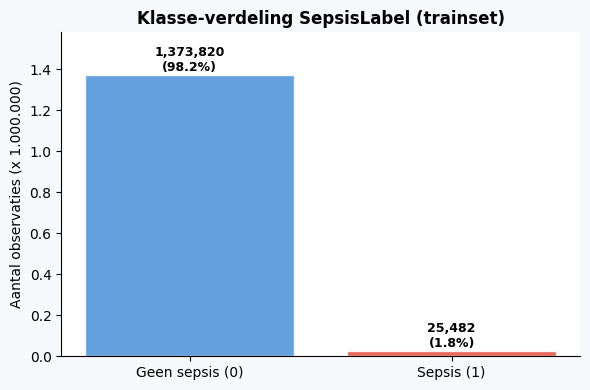

In [34]:
label_counts = df_train['SepsisLabel'].value_counts()
label_pct    = df_train['SepsisLabel'].value_counts(normalize=True).round(4) * 100

print('=== Klasse-verdeling SepsisLabel ===')
print(f'Geen sepsis (0): {label_counts[0]:>10,}  ({label_pct[0]:.2f}%)')
print(f'Sepsis     (1): {label_counts[1]:>10,}  ({label_pct[1]:.2f}%)')
print(f'Verhouding 0:1 = {label_counts[0]//label_counts[1]}:1')

fig, ax = plt.subplots(figsize=(6, 4), facecolor='#f7f9fc')
bars = ax.bar(['Geen sepsis (0)', 'Sepsis (1)'], label_counts.values,
              color=['#4a90d9', '#e74c3c'], edgecolor='white', alpha=0.85)
for bar, val, pct in zip(bars, label_counts.values, label_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(0, max(label_counts.values) * 1.15)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x / 1_000_000:,.1f}"))
ax.set_title('Klasse-verdeling SepsisLabel (trainset)', fontsize=12, fontweight='bold')
ax.set_ylabel('Aantal observaties (x 1.000.000)')
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

Er is een sterke **klasse-onbalans**: slechts 1,82% van de observaties heeft een sepsislabel. Een naïef model dat altijd 0 voorspelt behaalt al 98,18% accuracy. Dit maakt accuracy een ongeschikte metric; we focussen op AUROC, recall en precision.

### Missende waarden

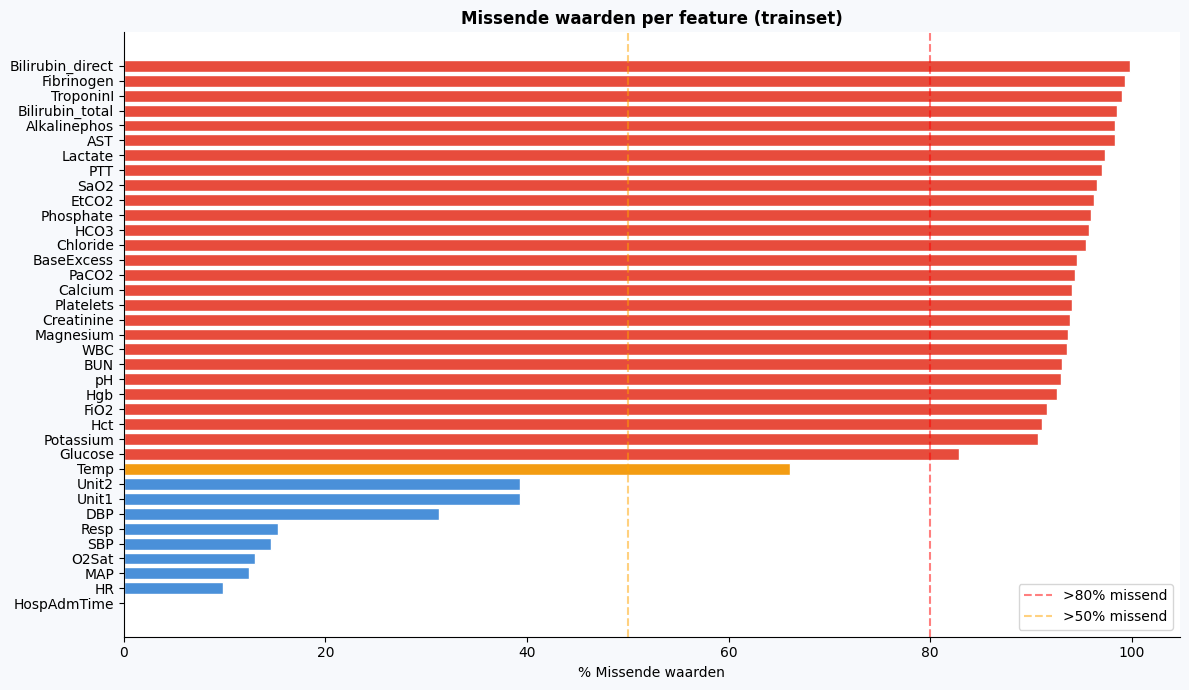

Features met > 80% missende waarden: 27
Features met 50% - 80% missende waarden : 1
Features met < 50% missende waarden (> 0%): 9
Features zonder missende waarden : 7


In [35]:
missing = (df_train.isnull().sum() / len(df_train) * 100).sort_values(ascending=False)
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ['Feature', 'Missing (%)']

fig, ax = plt.subplots(figsize=(12, 7), facecolor='#f7f9fc')
colors = ['#e74c3c' if v > 80 else '#f39c12' if v > 50 else '#4a90d9' 
          for v in missing_df['Missing (%)']]
ax.barh(missing_df['Feature'][::-1], missing_df['Missing (%)'][::-1],
        color=colors[::-1], edgecolor='white')
ax.axvline(x=80, color='red', linestyle='--', alpha=0.5, label='>80% missend')
ax.axvline(x=50, color='orange', linestyle='--', alpha=0.5, label='>50% missend')
ax.set_xlabel('% Missende waarden')
ax.set_title('Missende waarden per feature (trainset)', fontsize=12, fontweight='bold')
ax.legend()
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Features met > 80% missende waarden: {(missing > 80).sum()}')
print(f'Features met 50% - 80% missende waarden : {((missing > 50) & (missing <= 80)).sum()}')
print(f'Features met < 50% missende waarden (> 0%): {((missing > 0) & (missing <= 50)).sum()}')
print(f'Features zonder missende waarden : {(missing == 0).sum()}')

De meeste laboratoriumwaarden hebben een hoog percentage missende waarden. Dit is, nogmaals logisch, want laboratoriumtests worden niet elk uur afgenomen. Vitale parameters (HR, O2Sat, SBP, MAP, Resp) hebben minder missende waarden en worden continu gemonitord.

### Distributie vitale parameters

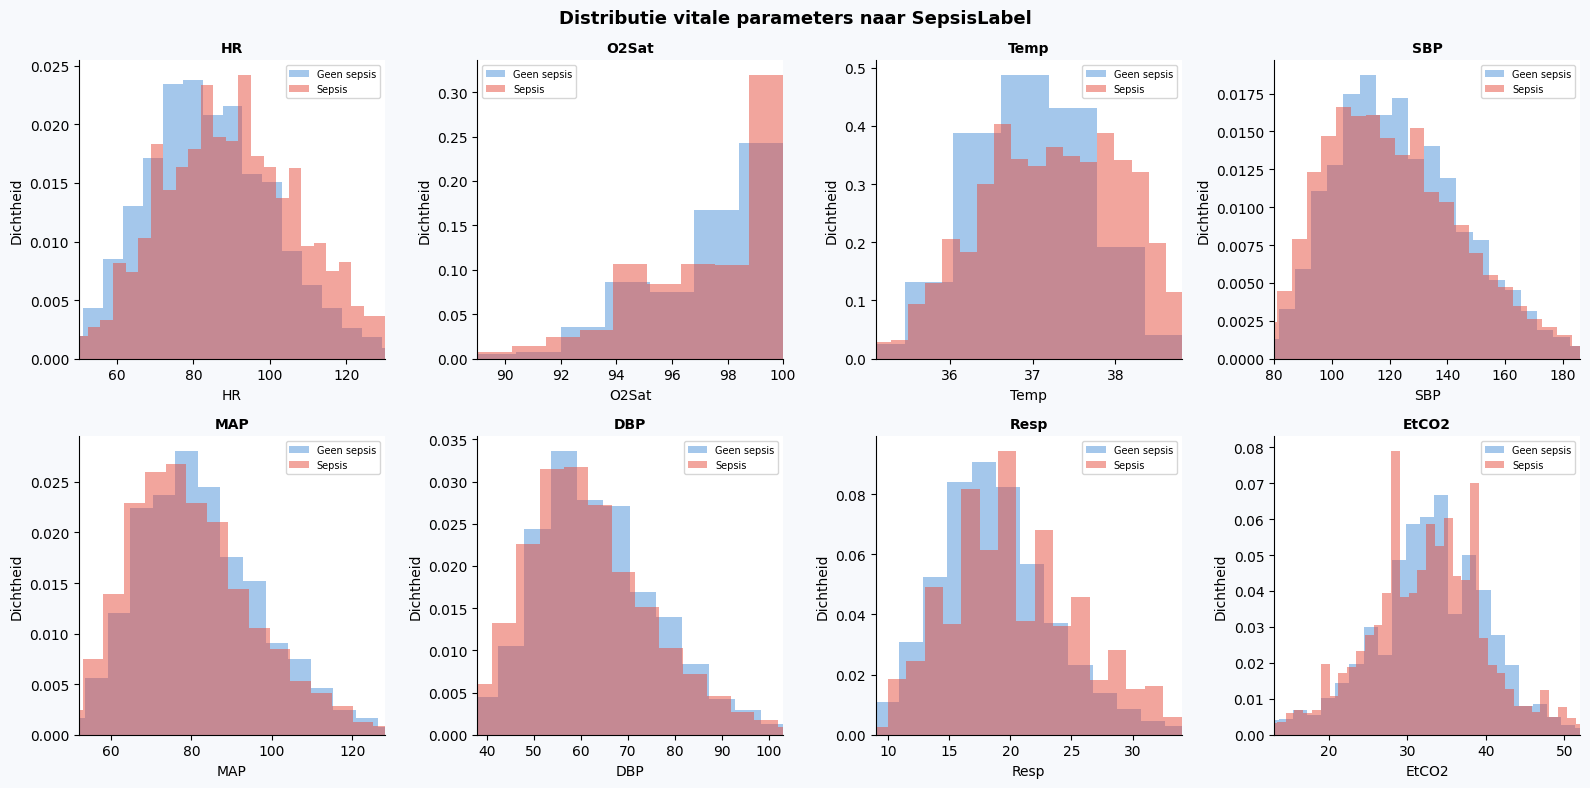

In [36]:
vital_cols = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2']

fig, axes = plt.subplots(2, 4, figsize=(16, 8), facecolor='#f7f9fc')
fig.suptitle('Distributie vitale parameters naar SepsisLabel', fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten(), vital_cols):
    for label, color, name in [(0, '#4a90d9', 'Geen sepsis'), (1, '#e74c3c', 'Sepsis')]:
        data = df_train[df_train['SepsisLabel'] == label][col].dropna()
        ax.hist(data, bins=50, alpha=0.5, color=color, label=name, density=True)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Dichtheid')
    ax.legend(fontsize=7)
    ax.set_facecolor('white')
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

    # Clip x-axis to 1st–99th percentile of the column
    col_data = df_train[col].dropna()
    ax.set_xlim(col_data.quantile(0.01), col_data.quantile(0.99))

plt.tight_layout()
plt.show()

* **HR (hartslag):** Sepsispatiënten hebben een iets hogere hartslag — de rode verdeling ligt meer naar rechts. Logisch: tachycardie is een klassiek sepsisteken.
* **O2Sat (zuurstofsaturatie):** Beide groepen zitten hoog (>90%), maar sepsis heeft meer spreiding naar lagere waarden. De piek bij 100% is voor beide groepen sterk alleen bij sepsis sterker.
* **Temp (temperatuur):** sepsis heeft een bredere spreiding aan beide kanten van normaal (~37°C). Zowel koorts als hypothermie zijn sepsistekenen — dit is zichtbaar in de plattere rode verdeling.
* **SBP (systolische bloeddruk):** Sepsispatiënten hebben een licht lagere SBP — rode verdeling iets naar links verschoven. Hypotensie is een sepsisteken, maar het verschil is subtiel.
* **MAP (gemiddelde arteriële druk):** Vergelijkbaar patroon als SBP: sepsis ligt iets lager. MAP <65 mmHg is klinisch een alarmgrens — beide verdelingen overlappen sterk onder de 80.
* **DBP (diastolische bloeddruk):** Verdelingen overlappen sterk, weinig onderscheid. Beide pieken liggen rond de 55–65.
* **Resp (ademhalingsfrequentie):** Een van de meest onderscheidende parameters: sepsispatiënten ademen sneller, rode verdeling duidelijk naar rechts verschoven.
* **EtCO2:** Veel spreiding, hoop missende waarden (52K EtCO2 dat vs 1.4M observaties) — waarnemingen zijn daardoor minder betrouwbaar omdat het geen representatief beeld geeft van alle patiënten, niet omdat het een steekproef is. Met de data die beschikbaar is, is te zien dat de verdeling redeljk gelijk loopt met 2 opvallende pieken voor sepsis bij c.a. 30 en 40 mm Hg.

Dus HR en Resp, waar de rode en blauwe verdeling zichtbaar verschoven zijn, suggereren dat die features nuttig kunnen zijn voor het model. DBP, waar de verdelingen vrijwel volledig overlappen, suggereert weinig toegevoegde waarde.

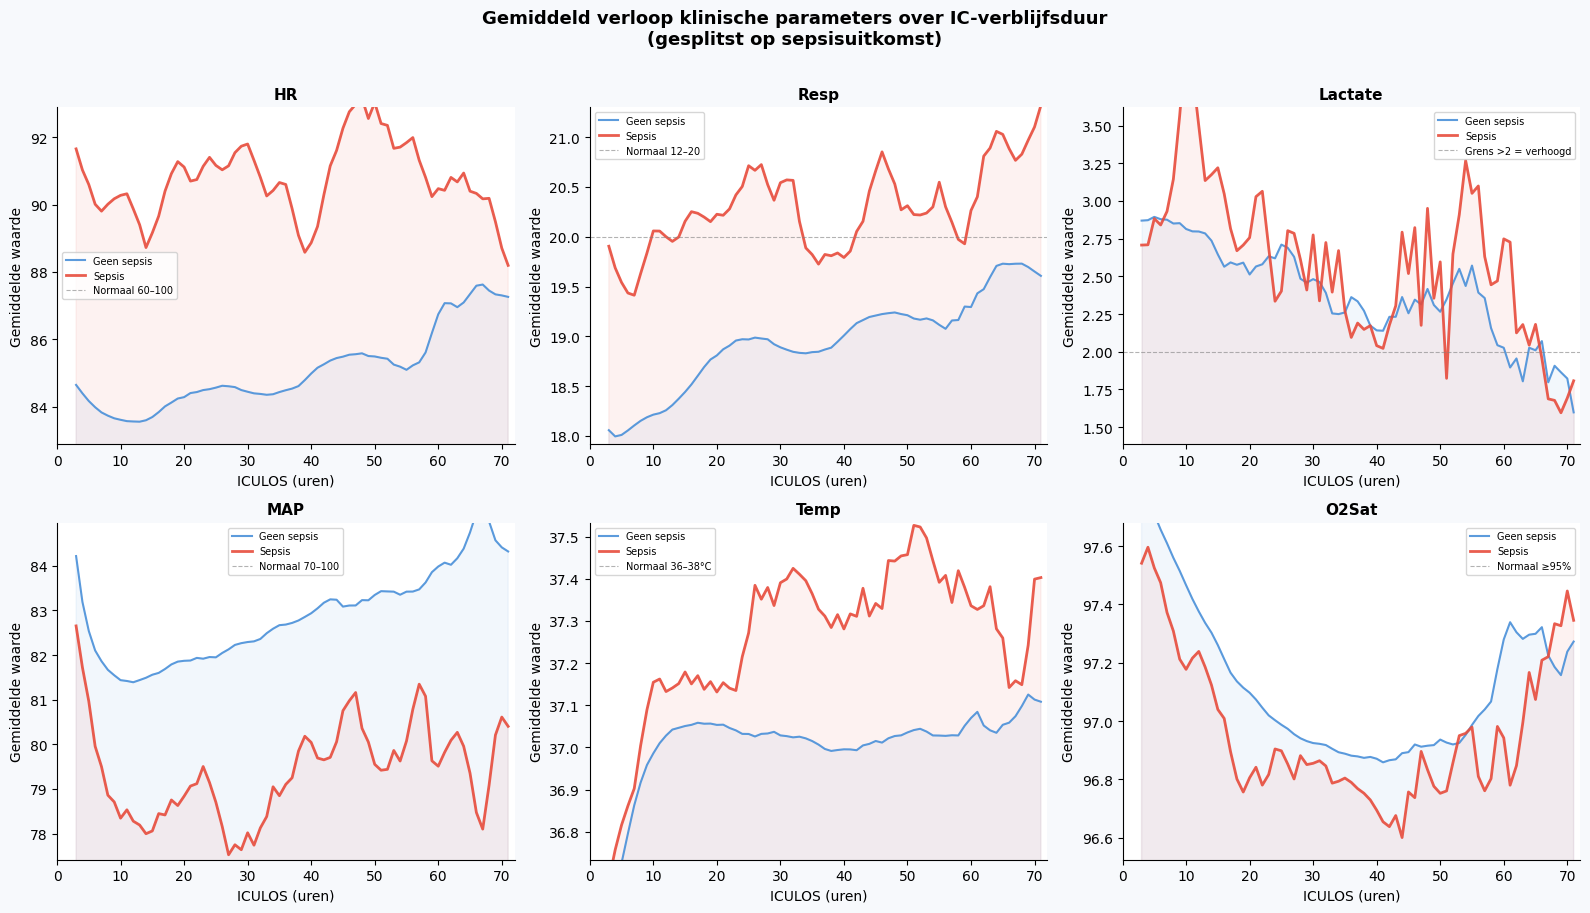

In [37]:
vitals_time = ['HR', 'Resp', 'Lactate', 'MAP', 'Temp', 'O2Sat']

df_time = df_train[df_train['ICULOS'] <= 72].copy()

trend = (
    df_time.groupby(['ICULOS', 'SepsisLabel'])[vitals_time]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(2, 3, figsize=(16, 9), facecolor='#f7f9fc')
fig.suptitle('Gemiddeld verloop klinische parameters over IC-verblijfsduur\n(gesplitst op sepsisuitkomst)',
             fontsize=13, fontweight='bold', y=1.01)

reference_lines = {
    'HR':      (60, 100, 'Normaal 60–100'),
    'Resp':    (12, 20,  'Normaal 12–20'),
    'MAP':     (70, 100, 'Normaal 70–100'),
    'Temp':    (36, 38,  'Normaal 36–38°C'),
    'O2Sat':   (95, 100, 'Normaal ≥95%'),
    'Lactate': (None, 2, 'Grens >2 = verhoogd'),
}

for ax, col in zip(axes.flatten(), vitals_time):
    for label, color, name, lw in [(0, '#4a90d9', 'Geen sepsis', 1.5),
                                    (1, '#e74c3c', 'Sepsis',      2.0)]:
        subset = trend[trend['SepsisLabel'] == label]
        y = subset.set_index('ICULOS')[col].rolling(3, center=True).mean()
        ax.plot(y.index, y.values, color=color, linewidth=lw, label=name, alpha=0.9)
        ax.fill_between(y.index, y.values, alpha=0.07, color=color)

    if col in reference_lines:
        low, high, label_ref = reference_lines[col]
        if low is not None:
            ax.axhline(low, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.axhline(high, color='gray', linestyle='--', linewidth=0.8, alpha=0.6,
                   label=label_ref)

    # Automatische y-as op basis van data
    y_all = trend[col].dropna()
    y_min = y_all.quantile(0.05)
    y_max = y_all.quantile(0.95)
    margin = (y_max - y_min) * 0.10
    ax.set_ylim(y_min - margin, y_max + margin)

    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('ICULOS (uren)')
    ax.set_ylabel('Gemiddelde waarde')
    ax.legend(fontsize=7)
    ax.set_facecolor('white')
    ax.set_xlim(0, 72)
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

* **HR (hartslag):** Sepsispatiënten hebben consistent gemiddeld een hogere hartslag gedurende het hele IC-verblijf. Het verschil is al zichtbaar vanaf uur 1 en blijft aanhouden, wat suggereert dat verhoogde HR een vroeg en aanhoudend sepsisteken is. Aan het einde van de uren in de IC is de hartslag van de patienten zonder en met sepsis het dichtst bij elkaar.
* **Resp (ademhalingsfrequentie):** Sepsis ligt vrijwel de hele opname boven de bovengrens van normaal van 20. Niet-sepsis stijgt geleidelijk maar blijft lager. Patienten met en zonder sepsis maken een stijging mee, wel valt op dat de stijging voor patienten zonder sepsis minder fluctueert.
* **Lactate:** Beide groepen starten boven de alarmgrens van 2 mmol/L, maar sepsis begint hoger en blijft instabieler. Opvallend: na ~10 uur daalt lactate bij beide groepen richting normaal. Dit kan betekenen dat patiënten al behandeld worden op de IC, waardoor lactate daalt ongeacht sepsisuitkomst.
* **MAP (gemiddelde arteriële druk):** Omgekeerd patroon: niet-sepsis heeft een hogere MAP dan sepsis. Sepsis zit vaker onder de klinische alarmgrens van 70 mmHg. Het verschil is zichtbaar maar de lijnen lopen dicht bij elkaar — minder sterk onderscheidend dan HR of Resp.
* **Temp (temperatuur):** Sepsispatiënten hebben een licht hogere temperatuur aan het begin van het verblijf, na verloop vergroot het verschil. Consistent zitten de patienten met sepsis binnen het normale bereik maar aan de bovenkant. Het verschil is klein (~0.2°C gemiddeld). Visueel is er een verschil aanwezig maar klinisch is het verschil klein.
* **O2Sat (zuurstofsaturatie):** Sepsis heeft een lagere O2Sat gedurende het verblijf, met name in de eerste uren. Beide groepen dalen rond uur 10–15 en herstellen daarna, ze volgen allebei hetzelfde patroon. Wat wel verschilt is dat de patienten zonder sepsis een vloeiendere lijn meemaken waar er voor sepsis patienten veel fluctuatie plaats vindt.

Dit laat zien dat de verschillen tussen sepsis en niet-sepsis consistent over tijd zijn, niet alleen gemiddeld. Vooral HR en Resp zijn al vroeg in het IC-verblijf afwijkend — wat relevant is voor vroegtijdige sepsissignalering.

### Correlatiematrices alle data groepen

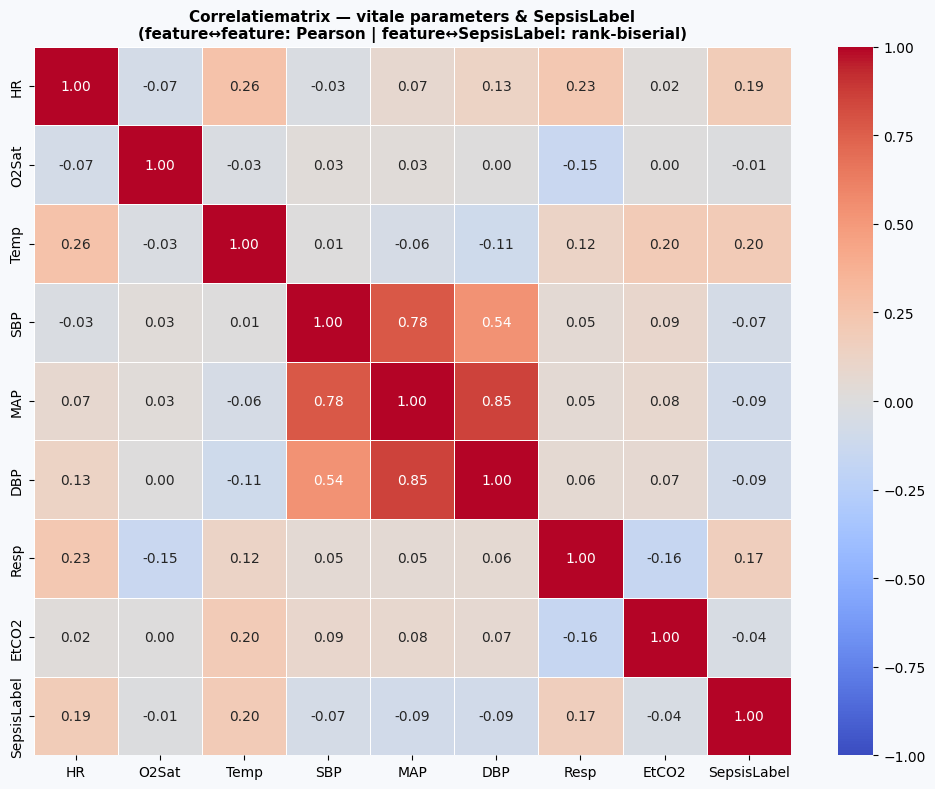

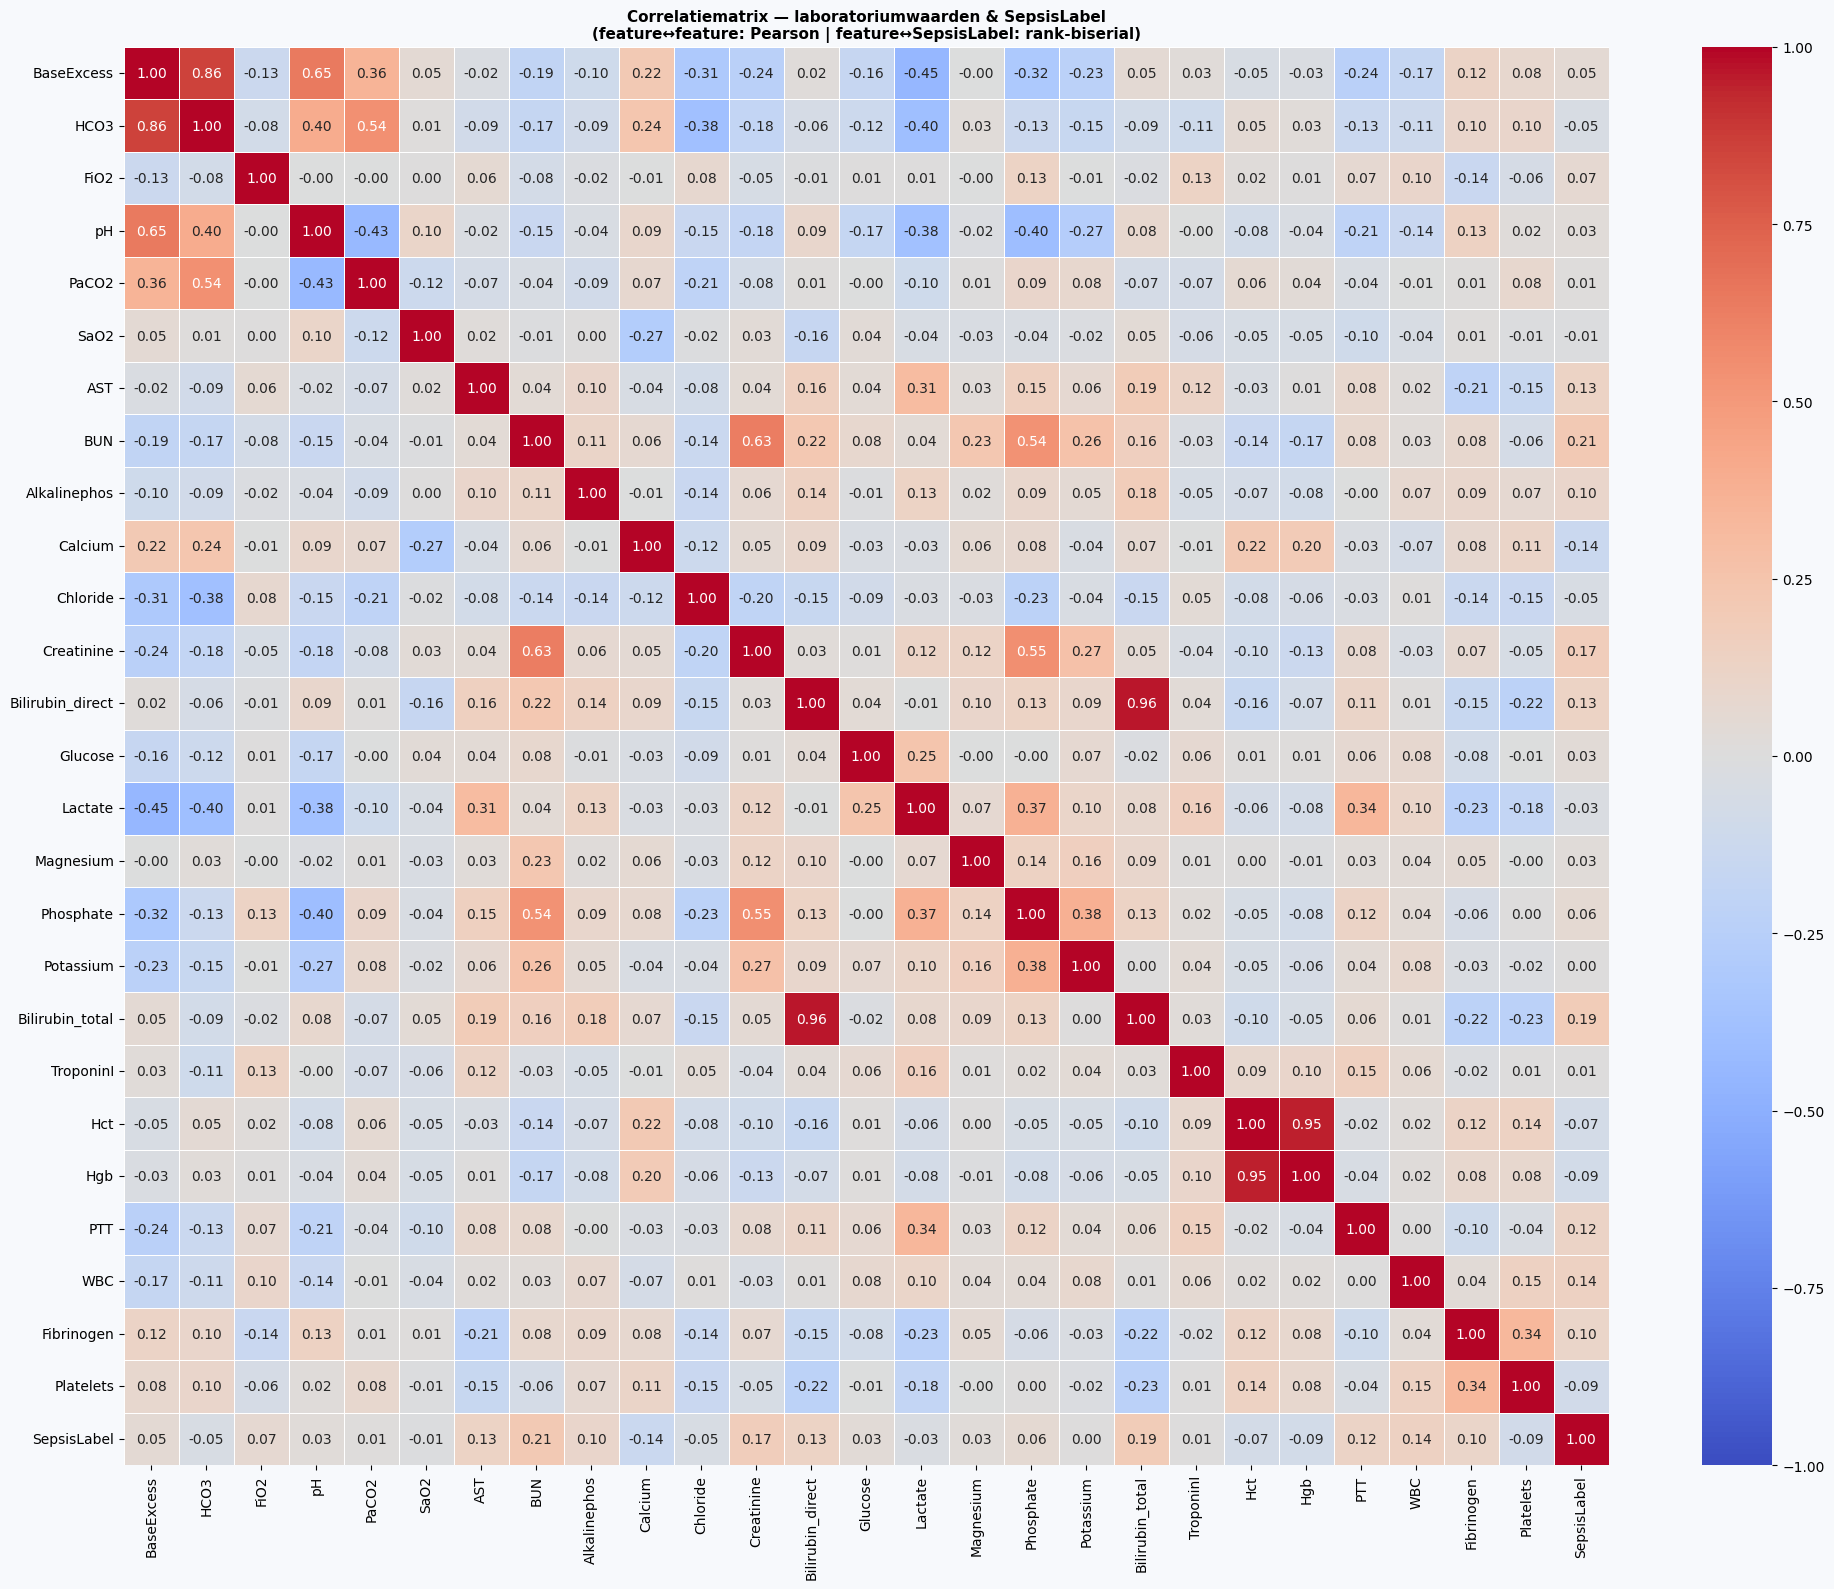

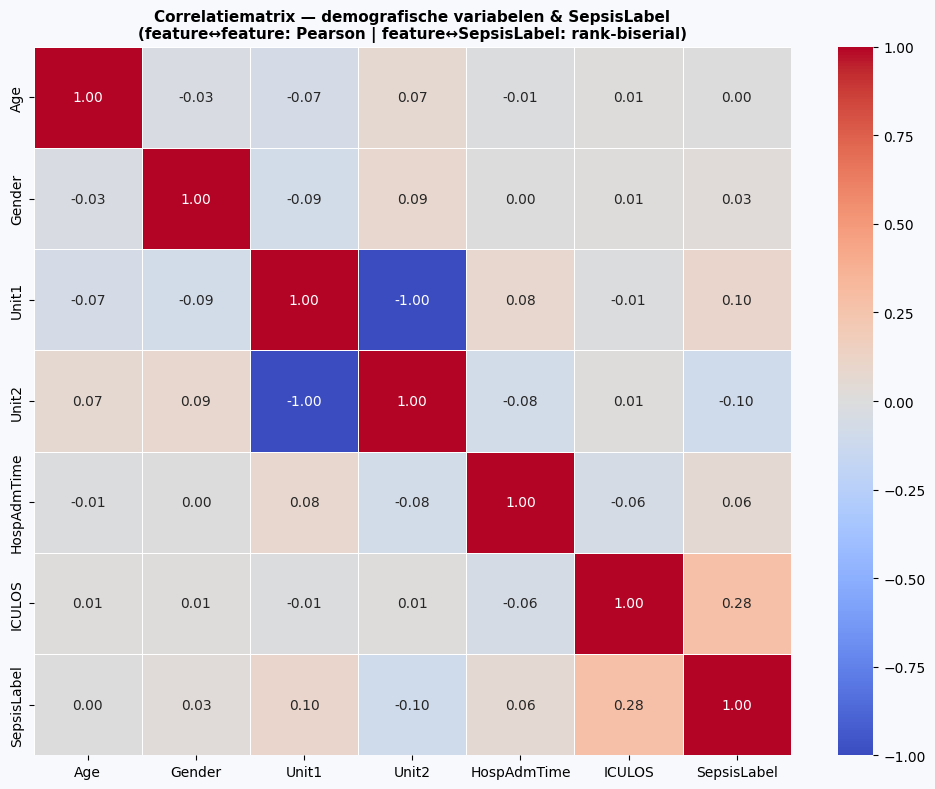

In [38]:
def corr_matrix_with_rb(df, cols, title, figsize):
    matrix = df[cols].corr()
    for col in cols:
        if col == 'SepsisLabel':
            matrix.loc[col, col] = 1.0
            continue
        valid = df[[col, 'SepsisLabel']].dropna()
        if len(valid) < 100:
            continue
        auc = roc_auc_score(valid['SepsisLabel'], valid[col])
        r_rb = 2 * (auc - 0.5)
        matrix.loc[col, 'SepsisLabel'] = r_rb
        matrix.loc['SepsisLabel', col] = r_rb
    fig, ax = plt.subplots(figsize=figsize, facecolor='#f7f9fc')
    sns.heatmap(matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                ax=ax, linewidths=0.5, vmin=-1, vmax=1)
    ax.set_title(f'{title}\n(feature↔feature: Pearson | feature↔SepsisLabel: rank-biserial)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

vital_cols = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'SepsisLabel']
corr_matrix_with_rb(df_train, vital_cols, 'Correlatiematrix — vitale parameters & SepsisLabel', (10, 8))

lab_cols = ['BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos',
            'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate',
            'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct',
            'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'SepsisLabel']
corr_matrix_with_rb(df_train, lab_cols, 'Correlatiematrix — laboratoriumwaarden & SepsisLabel', (20, 16))

demo_cols = ['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel']
corr_matrix_with_rb(df_train, demo_cols, 'Correlatiematrix — demografische variabelen & SepsisLabel', (10, 8))


**Correlatiematrix 1 — Vitale parameters**
De sterkste correlaties met SepsisLabel zijn Temp (0.20), HR (0.19) en Resp (0.17) deze hebben een positieve correlatie, dus hogere waarden hangen samen met sepsis. Dit sluit aan bij klinische sepsiscriteria: koorts, 
tachycardie en tachypneu zijn klassieke vroege signalen van sepsis. O2Sat (-0.01) en EtCO2 (-0.04) hebben 
vrijwel geen lineaire relatie met SepsisLabel.

**Correlatiematrix 2 — Laboratoriumwaarden**
De sterkste correlaties met SepsisLabel zijn Lactate (0.34) en BUN (0.21). Verhoogde lactaat 
en ureum zijn bekende sepsismarkers die wijzen op orgaanschade. Creatinine (0.17) heeft ook een 
lichte positieve relatie, wat past bij nierfunctieverlies als sepsiscomplicatie. De meeste overige 
laboratoriumwaarden hebben een zeer zwakke relatie met SepsisLabel (<0.15).

**Correlatiematrix 3 — Demografische variabelen**
De sterkste relatie met SepsisLabel is ICULOS (0.28) — patiënten die langer op de IC liggen 
hebben een hogere kans op sepsis, wat logisch is. Age (0.00) en Gender (0.03) hebben 
vrijwel geen directe lineaire relatie met SepsisLabel.

**Voorspellend vermogen**
Geen enkele feature heeft een hele sterke lineaire relatie met sepsis — de hoogste correlatie is 
Lactate (0.34). Dit suggereert dat sepsis niet door één of twee duidelijke markers wordt bepaald, 
maar door een combinatie van zwakkere signalen. Tree-based modellen zoals Random Forest en 
Gradient Boosting zijn beter in staat om dergelijke niet-lineaire combinaties te detecteren dan 
Logistic Regression.

### Correlatie sepsis met gemeten data

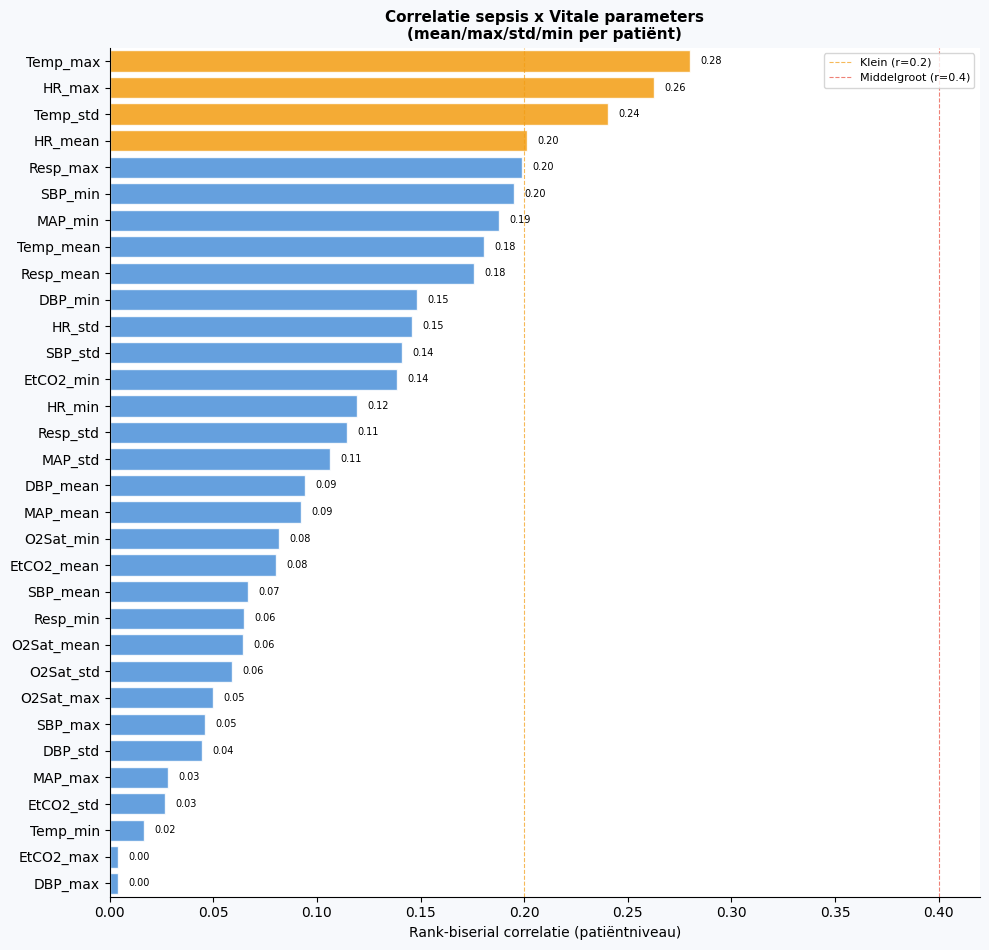

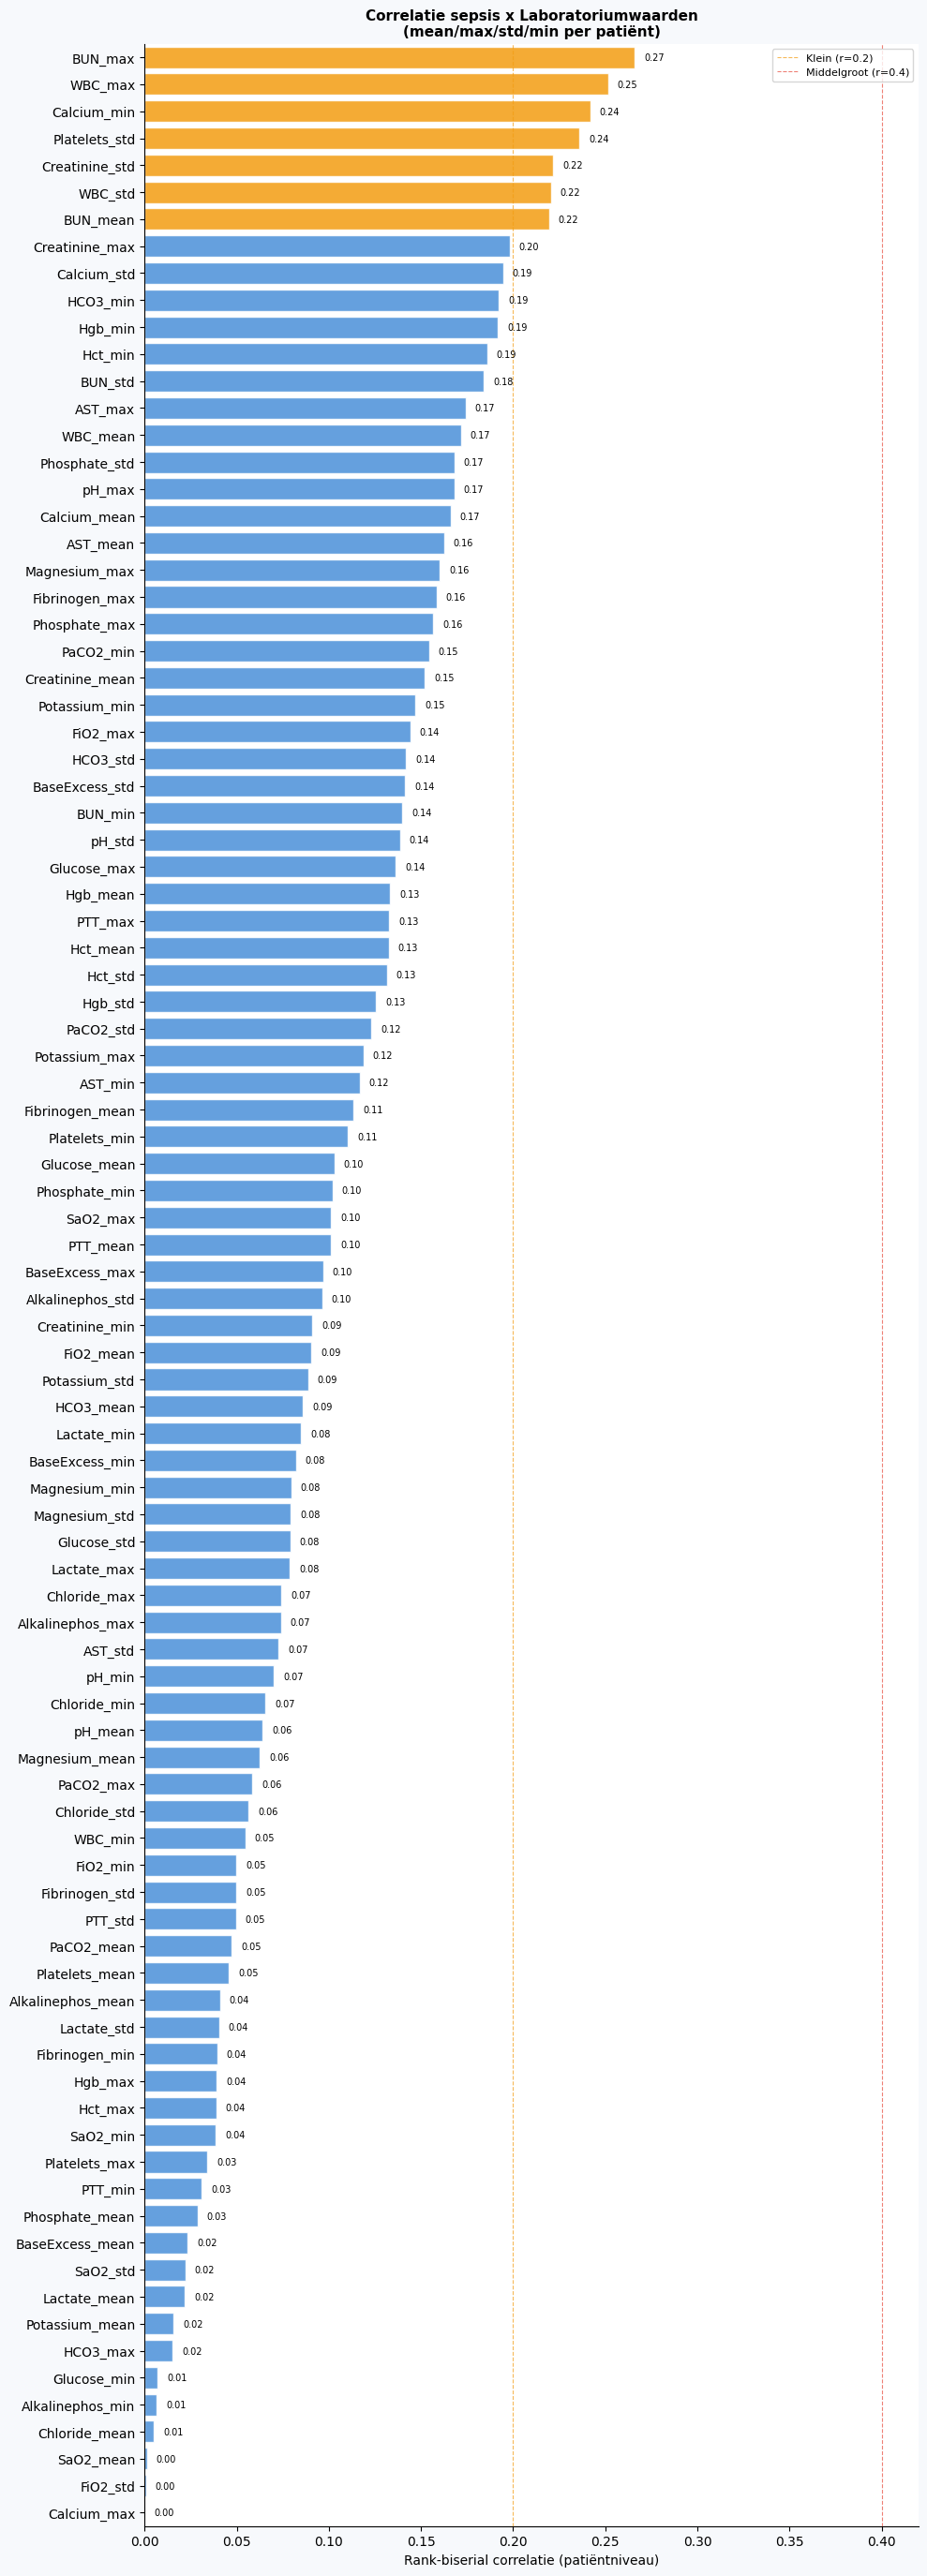

In [39]:
feature_groups = {
    'Vitale parameters': ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2'],
    'Laboratoriumwaarden': ['BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
                            'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Glucose',
                            'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Hct', 'Hgb',
                            'PTT', 'WBC', 'Fibrinogen', 'Platelets']
                            }

def cohens_d(g1, g2):
    pooled = np.sqrt(((len(g1)-1)*g1.std()**2 + (len(g2)-1)*g2.std()**2) / (len(g1)+len(g2)-2))
    return (g1.mean() - g2.mean()) / pooled if pooled > 0 else 0

# Patient-level aggregation
agg_dict = {col: ['mean', 'max', 'std', 'min']
            for cols in feature_groups.values() for col in cols}
agg_dict['SepsisLabel'] = 'max'

df_pat = df_train.groupby('Patient_ID').agg(agg_dict)
df_pat.columns = ['_'.join(c) for c in df_pat.columns]
df_pat = df_pat.rename(columns={'SepsisLabel_max': 'sepsis'}).reset_index()

sepsis_pat    = df_pat[df_pat['sepsis'] == 1]
no_sepsis_pat = df_pat[df_pat['sepsis'] == 0]

for group_name, cols in feature_groups.items():
    feature_cols = [f'{col}_{agg}' for col in cols for agg in ['mean', 'max', 'std', 'min']
                    if f'{col}_{agg}' in df_pat.columns]

    results = []
    for col in feature_cols:
        valid = df_pat[['sepsis', col]].dropna()
        if valid['sepsis'].nunique() < 2 or len(valid) < 50:
            continue
        auc = roc_auc_score(valid['sepsis'], valid[col])
        r_rb = 2 * (max(auc, 1-auc) - 0.5)
        d = abs(cohens_d(sepsis_pat[col].dropna(), no_sepsis_pat[col].dropna()))
        results.append({'feature': col, 'AUROC': max(auc, 1-auc), 'rank_biserial': r_rb, 'cohens_d': d})

    res_df = pd.DataFrame(results).sort_values('rank_biserial', ascending=False)

    fig, ax = plt.subplots(figsize=(10, max(4, len(res_df) * 0.3)), facecolor='#f7f9fc')
    colors = ['#e74c3c' if v >= 0.4 else '#f39c12' if v >= 0.2 else '#4a90d9'
              for v in res_df['rank_biserial']]
    ax.barh(res_df['feature'][::-1], res_df['rank_biserial'][::-1],
            color=colors[::-1], alpha=0.85, edgecolor='white')
    ax.set_ylim(-0.5, len(res_df) - 0.5)
    ax.axvline(0.2, color='#f39c12', linestyle='--', linewidth=0.8, alpha=0.7, label='Klein (r=0.2)')
    ax.axvline(0.4, color='#e74c3c', linestyle='--', linewidth=0.8, alpha=0.7, label='Middelgroot (r=0.4)')
    for i, (_, row) in enumerate(res_df[::-1].iterrows()):
        ax.text(row['rank_biserial'] + 0.005, i, f"{row['rank_biserial']:.2f}",
                va='center', fontsize=7)
    ax.set_xlabel('Rank-biserial correlatie (patiëntniveau)')
    ax.set_title(f'Correlatie sepsis x {group_name}\n(mean/max/std/min per patiënt)',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_facecolor('white')
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.show()


**Correlatie vitale parameters**\
De sterkste correlaties zijn Temp_max (0.28), HR_max (0.26) en Temp_std (0.24) — alle drie oranje omdat ze boven de kleine effectgrens (r=0.2) uitkomen. Opvallend is dat het de maximumwaarden zijn die het meest voorspellend zijn, niet de gemiddelden. Dit suggereert dat piekwaarden tijdens het IC-verblijf meer zeggen over sepsisrisico dan de gemiddelde toestand. Temp_std is interessant: hoge fluctuatie in temperatuur is een sterkere indicator dan de gemiddelde temperatuur zelf. Geen enkele feature haalt de middelgrote effectgrens (r=0.4) — alle correlaties blijven zwak.

**Correlatie laboratoriumwaarden**\
De sterkste correlaties zijn BUN_max (0.37), WBC_max (0.35) en Calcium_min (0.34). Ook hier zijn het voornamelijk maximum- en minimumwaarden die het meest correleren, niet de gemiddelden. BUN (ureum) en WBC (witte bloedcellen) zijn bekende infectie- en sepsismarkers. Calcium_min is klinisch logisch: hypocalciëmie komt voor bij ernstige sepsis. Ook hier haalt niets de middelgrote effectgrens van 0.4.

**Algemene conclusie over beide grafieken**\
De aggregaties _max en _min zijn consistent informatiever dan _mean — het model profiteert dus van de feature engineering waarbij meerdere aggregaties per patiënt worden berekend. Tegelijkertijd blijven alle correlaties zwak, wat de eerder genoemde verwachting bevestigt dat het model moeite zal hebben met precision.

### Patienten vrouw vs man & leeftijd

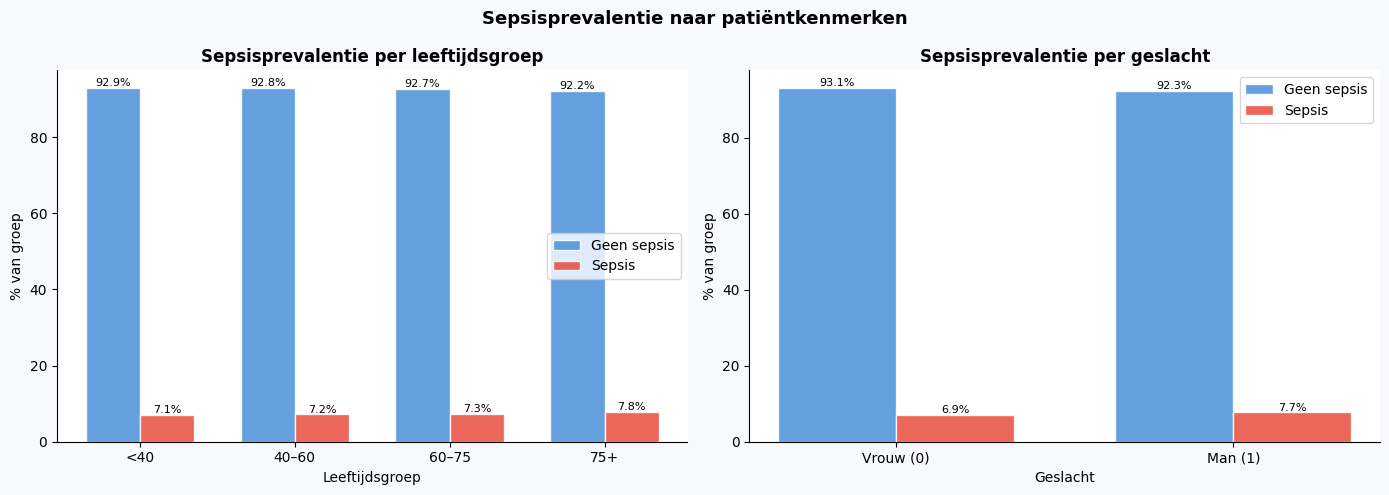

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#f7f9fc')
fig.suptitle('Sepsisprevalentie naar patiëntkenmerken', fontsize=13, fontweight='bold')

df_patients = df_train.groupby('Patient_ID').agg(
    Age=('Age', 'first'),
    Gender=('Gender', 'first'),
    sepsis=('SepsisLabel', 'max')
).reset_index()

df_patients['leeftijdsgroep'] = pd.cut(df_patients['Age'],
    bins=[0, 40, 60, 75, 120],
    labels=['<40', '40–60', '60–75', '75+'])

# Leeftijd
ax = axes[0]
prev_age = df_patients.groupby('leeftijdsgroep', observed=True)['sepsis'].mean() * 100
no_sepsis_age = 100 - prev_age
x = np.arange(len(prev_age))
width = 0.35
b1 = ax.bar(x - width/2, no_sepsis_age.values, width, label='Geen sepsis', color='#4a90d9', alpha=0.85, edgecolor='white')
b2 = ax.bar(x + width/2, prev_age.values, width, label='Sepsis', color='#e74c3c', alpha=0.85, edgecolor='white')
for bar, val in zip(b1, no_sepsis_age.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontsize=8)
for bar, val in zip(b2, prev_age.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontsize=8)
ax.set_title('Sepsisprevalentie per leeftijdsgroep', fontweight='bold')
ax.set_xlabel('Leeftijdsgroep')
ax.set_ylabel('% van groep')
ax.set_xticks(x)
ax.set_xticklabels(prev_age.index)
ax.legend()
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

# Geslacht
ax = axes[1]
prev_gender = df_patients.groupby('Gender')['sepsis'].mean() * 100
no_sepsis_gender = 100 - prev_gender
x = np.arange(2)
b1 = ax.bar(x - width/2, no_sepsis_gender.values, width, label='Geen sepsis', color='#4a90d9', alpha=0.85, edgecolor='white')
b2 = ax.bar(x + width/2, prev_gender.values, width, label='Sepsis', color='#e74c3c', alpha=0.85, edgecolor='white')
for bar, val in zip(b1, no_sepsis_gender.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontsize=8)
for bar, val in zip(b2, prev_gender.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontsize=8)
ax.set_title('Sepsisprevalentie per geslacht', fontweight='bold')
ax.set_xlabel('Geslacht')
ax.set_ylabel('% van groep')
ax.set_xticks(x)
ax.set_xticklabels(['Vrouw (0)', 'Man (1)'])
ax.legend()
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

* **Leeftijdsgroep:** De sepsisgevallen stijgen licht met leeftijd: van 7.1% bij patiënten onder 40 naar 7.8% bij 75+. Het verschil is klein maar consistent. Oudere patiënten hebben een iets hoger risico op sepsis, wat logisch is door verminderde afweer. Voor de fairness-analyse betekent dit dat het model mogelijk vaker geconfronteerd wordt met sepsisgevallen bij oudere patiënten, wat de prestaties per leeftijdsgroep kan beïnvloeden.
* **Geslacht:** Mannen hebben een iets hogere aantal sepsispregevallen dan vrouwen (7.7% vs 6.9%). Het verschil is beperkt; ongeveer 0.8 procentpunt verschil tussen vrouwen en mannen. Voor de fairness-analyse is dit relevant: als het model getraind wordt op een dataset met meer sepsisgevallen bij mannen, kan het voor vrouwen minder goed gevalideerd zijn.

De verschillen tussen groepen zijn in beide grafieken klein, wat positief is voor fairness: de dataset bevat geen extreme onevenwichtigheden in sepsisprevalentie tussen demografische groepen. Of het model ook daadwerkelijk gelijk presteert per groep wordt pas duidelijk in de fairness-analyse.

### Fairness — leeftijd & geslacht

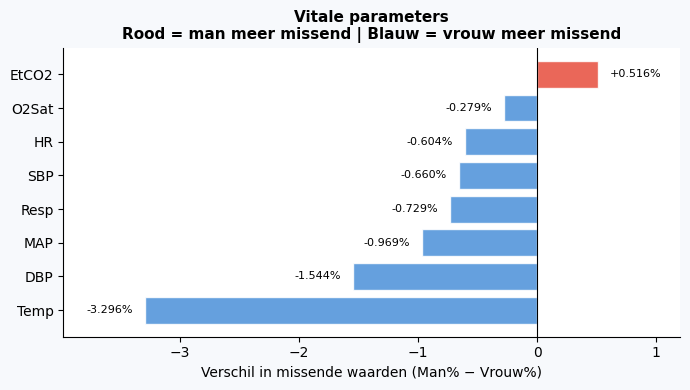

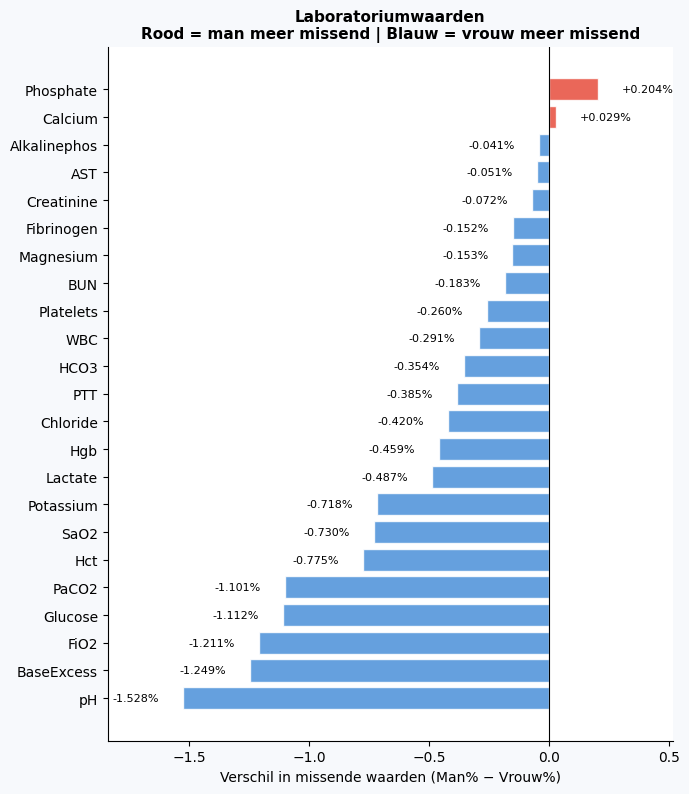

In [41]:
for (group_name, features) in feature_groups.items():
    features = [f for f in features if f in df_train.columns]
    
    vrouw = df_train[df_train['Gender'] == 0][features].isnull().mean() * 100
    man   = df_train[df_train['Gender'] == 1][features].isnull().mean() * 100
    diff  = man - vrouw  # positief = man heeft meer missend, negatief = vrouw heeft meer missend
    diff  = diff.sort_values()

    colors = ['#e74c3c' if v > 0 else '#4a90d9' for v in diff.values]

    fig, ax = plt.subplots(figsize=(7, max(4, len(features) * 0.35)), facecolor='#f7f9fc')
    bars = ax.barh(diff.index, diff.values, color=colors, alpha=0.85, edgecolor='white')
    
    for bar, val in zip(bars, diff.values):
        ax.text(val + (0.1 if val >= 0 else -0.1), bar.get_y() + bar.get_height()/2,
                f'{val:+.3f}%', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

    ax.axvline(0, color='black', linewidth=0.8)
    ax.margins(x=0.18)
    ax.set_xlabel('Verschil in missende waarden (Man% − Vrouw%)')
    ax.set_title(f'{group_name}\nRood = man meer missend | Blauw = vrouw meer missend',
                 fontweight='bold', fontsize=11)
    ax.set_facecolor('white')
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()

* **Vitale parameters:** De verschillen zijn klein: maximaal 3.3 procentpunt. Voor de meeste vitale parameters hebben vrouwen meer missende waarden dan mannen, met de kolom Temp als uitschieter (-3.3% meer missende waarden). EtCO2 is de enige waar mannen meer missend hebben (+0.5%). De verschillen zijn zo klein dat dit geen significante databias vormt voor het model.
* **Laboratoriumwaarden:** Opnieuw domineren de blauwe bars. Vrouwen hebben bij vrijwel alle laboratoriumwaarden iets meer missende waarden. De verschillen blijven onder de 1.6 procentpunt, wat minimaal is gezien het totale missende percentage van 90%+ per feature. Phosphate, TroponinI en Calcium zijn de enige drie waar mannen iets meer missend hebben, maar ook die verschillen zijn minimaal (<0.2%).
* **Demografisch:** Age, Gender en ICULOS hebben geen missende waarden voor beide groepen (+0.000%). HospAdmTime toont echt uiterst minimale verschillen tussen mannen en vrouwen met 0.001% meer missende waarden voor mannen. Dit heeft geen effect op de bias. Unit1 en Unit2 tonen een verschil van -2.7% — vrouwen hebben hier vaker een missende waarde dan mannen. 

**Algemene conclusie**\
De missende waarden zijn over geslacht zeer gelijkmatig verdeeld nergens een verschil groter dan 3.3 procentpunt. Wel is er een consistent patroon zichtbaar: vrouwen hebben bij vrijwel alle features iets meer missende waarden dan mannen. Dit suggereert een lichte maar structurele ondervertegenwoordiging van vrouwen in de meetdata. De verschillen zijn echter te klein om te spreken van een ernstige databias.

---

### Overzicht data understanding

Na analyse van de dataset komen de volgende inzichten naar voren:

- **Klasse-onbalans:** 1,82% sepsis — klasse-gewichten zijn noodzakelijk bij het trainen van modellen.
- **Missende waarden:** Laboratoriumwaarden ontbreken in 50–99% van de uurobservaties; imputation is vereist.
- **Vitale parameters:** Hartslag en ademfrequentie tonen verschuivingen bij sepsis; dit zijn klinisch verwachte predictors.
- **Leeftijd:** Sepsispatiënten zijn gemiddeld iets ouder; leeftijd is een relevante feature.
- **Geslacht:** Kleine verschillen in sepsispercentage tussen mannen en vrouwen — fairnessanalyse is relevant.


---

## Ethische overwegingen
**Klasse-onbalans:** De sterke klasse-onbalans (98,2% vs 1,8%) heeft directe ethische implicaties. Een model dat de minderheidsklasse (sepsis) mist, laat patiënten in de steek die acute zorg nodig hebben. Het gebruik van accuracy als metric zou dit probleem bedekken, hierdoor moet deze metric niet gebruikt worden. Het is ethisch noodzakelijk om recall en f1-macro voor de sepsisklasse als primaire metric te hanteren en klasse-gewichten in te stellen.

**Fairness bij geslacht en leeftijd:** Uit de data blijkt dat er kleine verschillen zijn in sepsisgevallen tussen geslachten en leeftijdsgroepen. Als het model systematisch slechter presteert voor vrouwen of oudere patiënten, leidt dit tot ongelijke zorg. Dit wordt expliciet onderzocht in de modelevaluatie.

---

## **RE1 - Data Preperation**

### Feature engineering en cleaning

In [42]:
# Kolommen die niet als features worden gebruikt
DROP_COLS = ['Unnamed: 0', 'Patient_ID', 'SepsisLabel', 'Hour']

# Klinische feature-groepen
VITAL_COLS = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2']
LAB_COLS   = ['BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
              'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct',
              'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium',
              'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
              'Fibrinogen', 'Platelets']
DEMO_COLS  = ['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS']
TARGET_COL   = 'SepsisLabel'


CLINICAL_COLS = VITAL_COLS + LAB_COLS  # kolommen waarvoor mean/min/max/std worden berekend
TOTAL = VITAL_COLS + LAB_COLS + DEMO_COLS # alle kolommen die als features worden gebruikt


print(f'Vitale parameters:   {len(VITAL_COLS)}')
print(f'Laboratoriumwaarden: {len(LAB_COLS)}')
print(f'Demografische data:  {len(DEMO_COLS)}')
print(f'Totaal: {len(TOTAL)}')

Vitale parameters:   8
Laboratoriumwaarden: 26
Demografische data:  6
Totaal: 40


Per patiënt worden vier statistische aggregaties berekend over de tijdreeks: **mean**, **min**, **max** en **std**. Dit levert een enkelvoudige rij per patiënt op die de volledige opname-periode samenvat. Demografische kenmerken worden als eerste observatie per patiënt meegenomen.

**Keuze mediaan-imputation:** Medische data bevat veel willekeurig ontbrekende waarden (tests worden niet elk uur afgenomen). Mediaan-imputation is robuust tegen uitbijters, wat bij klinische data vaak voorkomt.

**Feature-aggregaties:** Door mean/min/max/std per patiënt te berekenen kan het model zowel de gemiddelde toestand als extreme waarden en variabiliteit gebruiken voor voorspelling.

In [43]:
SAMPLE_FRAC = None 

def aggregate_patient_features(df, clinical_cols, demo_cols, target_col='SepsisLabel', sample_frac=None, random_state=42):

    if sample_frac is not None:
        pats = df['Patient_ID'].unique()
        rng  = np.random.default_rng(random_state)
        pats = rng.choice(pats, size=int(len(pats) * sample_frac), replace=False)
        df   = df[df['Patient_ID'].isin(pats)]

    # Mediaan-imputation vóór aggregatie
    df = df.copy()
    for col in clinical_cols:
        if col in df.columns and df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())

    # Aggregaties: mean, min, max, std voor klinische features
    agg_dict = {col: ['mean', 'min', 'max', 'std'] for col in clinical_cols if col in df.columns}
    # Demografische features: eerste observatie per patiënt
    for col in demo_cols:
        if col in df.columns:
            agg_dict[col] = 'first'
    if target_col in df.columns:
        agg_dict[target_col] = 'max'

    df_pat = df.groupby('Patient_ID').agg(agg_dict)
    df_pat.columns = ['_'.join(c) if isinstance(c, tuple) else c for c in df_pat.columns]

    # Hernoem target en demografische kolommen (verwijder '_first'/'_max' suffix)
    rename = {}
    if f'{target_col}_max' in df_pat.columns:
        rename[f'{target_col}_max'] = target_col
    for col in demo_cols:
        if f'{col}_first' in df_pat.columns:
            rename[f'{col}_first'] = col
    df_pat = df_pat.rename(columns=rename).reset_index()

    # Opvullen std-NaN (als slechts 1 observatie per patiënt)
    std_cols = [c for c in df_pat.columns if c.endswith('_std')]
    df_pat[std_cols] = df_pat[std_cols].fillna(0)

    # Opvullen overige NaN (demografische kolommen zoals Unit1, Unit2, HospAdmTime)
    df_pat = df_pat.fillna(0)

    return df_pat


# Trainset aggregeren
df_pat_train = aggregate_patient_features(
    df_train, CLINICAL_COLS, DEMO_COLS,
    target_col='SepsisLabel', sample_frac=SAMPLE_FRAC
)

# Testset aggregeren (geen target)
df_pat_test = aggregate_patient_features(
    df_test, [c for c in CLINICAL_COLS if c in df_test.columns],
    [c for c in DEMO_COLS if c in df_test.columns],
    target_col=None, sample_frac=None
)

print(f'Trainset (patiëntniveau): {df_pat_train.shape[0]:,} patiënten, {df_pat_train.shape[1]} features')
print(f'Testset  (patiëntniveau): {df_pat_test.shape[0]:,} patiënten, {df_pat_test.shape[1]} features')
print(f'Sepsis in trainset: {df_pat_train["SepsisLabel"].sum():,} ({df_pat_train["SepsisLabel"].mean()*100:.2f}%)')

Trainset (patiëntniveau): 36,336 patiënten, 144 features
Testset  (patiëntniveau): 4,000 patiënten, 143 features
Sepsis in trainset: 2,674 (7.36%)


**Mediaan-imputation:** Voordat er geaggregeerd wordt, worden missende waarden opgevuld met de mediaan van de kolom. Mediaan is robuuster dan gemiddelde bij klinische data omdat uitbijters, die bij IC-patiënten vaak voorkomen, de mediaan niet beïnvloeden.

**Aggregaties per patiënt:** Per patiënt worden vier statistische kenmerken berekend over de tijdreeks: mean, min, max en std. Dit reduceert de dataset van observatieniveau (1.4M rijen) naar patiëntniveau (36K rijen). De mean vangt de gemiddelde toestand, min/max de extreme waarden, en std de fysiologische instabiliteit gedurende het verblijf — wat zoals eerder gezien juist voorspellend is voor sepsis.

**Demografische features:** Leeftijd, geslacht en IC-gegevens worden als eerste observatie per patiënt meegenomen, omdat deze waarden niet veranderen over tijd.

**Target:** SepsisLabel wordt als maximum per patiënt genomen, dit houdt in: als een patiënt op enig moment sepsis ontwikkelt (label = 1), krijgt de patiënt overall label 1.

**Resultaat:** 36.336 patiënten met 144 features in de trainset. Het sepsispercentage stijgt van 1.82% op observatieniveau naar 7.36% op patiëntniveau — logisch, omdat één sepsispatiënt meerdere uren (observaties) heeft wanneer er sepsislabel nog 0 (geen sepsis) was, terwijl deze later bij een aandeel van de patienten verandert naar 1 (wel sepsis). Zoals eerder besproken krijgen deze patienten overal een label van 1, dus het aantal observaies bij patienten die wel sepsis hebben stijgt.

In [44]:
TARGET_COL   = 'SepsisLabel'
DROP_FROM_X  = ['Patient_ID', TARGET_COL] +                [c for c in ['Unnamed: 0', 'Hour'] if c in df_pat_train.columns]

FEATURE_COLS = [c for c in df_pat_train.columns if c not in DROP_FROM_X]

X_train = df_pat_train[FEATURE_COLS].copy()
y_train = df_pat_train[TARGET_COL].values

X_test_full = df_pat_test[[c for c in FEATURE_COLS if c in df_pat_test.columns]].copy()
# Ontbrekende features opvullen met 0
for col in FEATURE_COLS:
    if col not in X_test_full.columns:
        X_test_full[col] = 0
X_test_full = X_test_full[FEATURE_COLS]

print(f'Aantal features: {len(FEATURE_COLS)}')
print(f'Voorbeeld feature-namen: {FEATURE_COLS[:8]}')

Aantal features: 142
Voorbeeld feature-namen: ['HR_mean', 'HR_min', 'HR_max', 'HR_std', 'O2Sat_mean', 'O2Sat_min', 'O2Sat_max', 'O2Sat_std']


**Feature selectie:** Patient_ID en SepsisLabel worden uitgesloten — Patient_ID is een identifier zonder voorspellende waarde, en SepsisLabel is de target die het model moet voorspellen. Ook Hour en Unnamed: 0 worden verwijderd indien aanwezig. De overgebleven 144 features (mean/min/max/std per klinische feature + demografische variabelen) vormen de input voor de modellen.

**Trainset:** X_train bevat de 144 features voor alle 36.336 patiënten. y_train bevat de bijbehorende SepsisLabel (0 of 1).

**Testset:** De testset mist de SepsisLabel kolom. Dit is de onbekende waarde en moet worden voorspeld. Features die wel in de trainset maar niet in de testset zitten worden opgevuld met 0, zodat de feature matrix dezelfde structuur heeft als tijdens het trainen.

### Leeftijdsgroepen aanmaken (voor fairness-analyse)

In [45]:
def leeftijdsgroep(age):
    if age < 45:   return '<45'
    elif age < 65: return '45-64'
    elif age < 75: return '65-74'
    else:          return '75+'

df_pat_train['leeftijdsgroep'] = df_pat_train['Age'].apply(leeftijdsgroep)
df_pat_train['Gender_label']   = df_pat_train['Gender'].map({0: 'Vrouw', 1: 'Man'})

print('Klasse-verdeling per leeftijdsgroep:')
print(df_pat_train.groupby('leeftijdsgroep')['SepsisLabel'].value_counts(normalize=True).unstack().round(4) * 100)

print('\nKlasse-verdeling per geslacht:')
print(df_pat_train.groupby('Gender_label')['SepsisLabel'].value_counts(normalize=True).unstack().round(4) * 100)

Klasse-verdeling per leeftijdsgroep:
SepsisLabel         0     1
leeftijdsgroep             
45-64           92.82  7.18
65-74           92.65  7.35
75+             92.26  7.74
<45             92.76  7.24

Klasse-verdeling per geslacht:
SepsisLabel       0     1
Gender_label             
Man           92.31  7.69
Vrouw         93.07  6.93


**Fairness analyse**
Voor de fairness-analyse worden twee hulpkolommen aangemaakt: leeftijdsgroep (<45, 45-64, 65-74, 75+) en Gender_label (Vrouw/Man). Deze worden later gebruikt om de modelprestaties per subgroep te vergelijken.

**Grenswaarden**
De grenswaarden voor leeftijdsgroepen zijn klinisch gemotiveerd — 65 en 75 zijn gebruikelijke grenzen in medisch onderzoek die overeenkomen met verhoogd risico op complicaties bij ouderen.

**Klasse verdeling**
De klasse verdeling per leeftijdsgroep laat zien of het sepsispercentage gelijkmatig verdeeld is over leeftijdsgroepen. Dit is relevant voor de interpretatie van de fairness-resultaten. Als een leeftijdsgroep veel minder sepsisgevallen bevat, is de AUROC voor die groep minder betrouwbaar door de kleine steekproefgrootte.

---

## **DN1 en RE2 - Modeling**

In [46]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

scaler = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr)
X_val_sc = scaler.transform(X_val)

print(f'Trainset: {X_tr_sc.shape[0]:,} | Validatieset: {X_val_sc.shape[0]:,}')
print(f'Sepsis in train: {y_tr.sum():,} ({y_tr.mean()*100:.2f}%)')
print(f'Sepsis in val:   {y_val.sum():,} ({y_val.mean()*100:.2f}%)')

Trainset: 29,068 | Validatieset: 7,268
Sepsis in train: 2,139 (7.36%)
Sepsis in val:   535 (7.36%)


**Train/validatie split:** De data wordt opgesplitst in 80% trainset en 20% validatieset. stratify=y_train zorgt dat de verhouding sepsis/geen sepsis gelijk blijft in beide sets — zonder stratificatie bestaat het risico dat door toeval bijna alle sepsisgevallen in de trainset belanden, waardoor de validatieset niet representatief is.

**StandardScaler:** De features worden gestandaardiseerd naar mean=0 en std=1. Dit is vooral noodzakelijk voor Logistic Regression, die gevoelig is voor features met verschillende schalen — een feature in mmHg en een feature in mg/dL hebben anders veel verschillende invloed op het model. Voor Random Forest en Gradient Boosting maakt schaling geen verschil, maar het schaadt ook niet. De scaler wordt alleen gefit op de trainset (fit_transform) en vervolgens toegepast op de validatieset (transform). Als de scaler ook op de validatieset gefit zou worden, zou informatie uit de validatieset lekken naar het model hierdoor zou de evaluatie onbetrouwbaar zijn.

In [47]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, random_state=42, subsample=0.8
    ),
}

results   = {}
val_probs = {}

for name, model in models.items():
    print(f'Training: {name}...')
    if name == 'Gradient Boosting':
        sw = compute_sample_weight('balanced', y=y_tr)
        model.fit(X_tr_sc, y_tr, sample_weight=sw)
    else:
        model.fit(X_tr_sc, y_tr)
    
    preds = model.predict(X_val_sc)
    probs = model.predict_proba(X_val_sc)[:, 1]
    
    val_probs[name] = probs
    results[name] = {
        'preds': preds,
        'probs': probs,
        'auroc':     roc_auc_score(y_val, probs),
        'f1_macro':  f1_score(y_val, preds, average='macro'),
        'recall_1':  recall_score(y_val, preds),
        'precision_1': precision_score(y_val, preds),
        'avg_prec':  average_precision_score(y_val, probs),
    }

print(f'\n{"Model":23s} {"AUROC":>8} {"Recall":>8} {"Prec":>6} {"F1 macro":>10}')
print('-' * 65)
for name in models:
    r = results[name]
    print(f"{name:25s}  {r['auroc']:.3f}   {r['recall_1']:.3f}   {r['precision_1']:.3f}   {r['f1_macro']:.3f}")

print(f'\nKansen niveau (random AUROC): 0.500')

Training: Logistic Regression...


Training: Random Forest...
Training: Gradient Boosting...

Model                      AUROC   Recall   Prec   F1 macro
-----------------------------------------------------------------
Logistic Regression        0.821   0.718   0.210   0.597
Random Forest              0.857   0.013   0.778   0.494
Gradient Boosting          0.874   0.779   0.257   0.639

Kansen niveau (random AUROC): 0.500


**Drie modellen:**
- **Logistic Regression** — basismodel, goed interpreteerbaar, snel te trainen
- **Random Forest** — ensemble van beslisbomen, robuust en non-lineair
- **Gradient Boosting** — boosted ensemble, vaak beste performance bij tabular data

**Klasse-gewichten:** Alle drie de modellen krijgen een correctie voor de klasse-onbalans mee. Logistic Regression en Random Forest gebruiken class_weight='balanced', wat de minderheidsklasse (sepsis) automatisch zwaarder laat meewegen. Gradient Boosting ondersteunt dit parameter niet direct, dus wordt compute_sample_weight('balanced') gebruikt om hetzelfde effect te bereiken via sample weights.

**Evaluatie:** Train/validatie split (80/20) met stratificatie. Per model worden vier metrics berekend op de validatieset: AUROC, recall, precision en F1-macro.

**Metrics:**
* **AUROC (Area Under the ROC Curve)** — Meet hoe goed het model onderscheid maakt tussen sepsis en geen sepsis over alle mogelijke drempelwaarden. Een waarde van 1.0 is perfect, 0.5 is willekeurig. Het zegt niets over de concrete voorspellingen maar wel over het algemene onderscheidend vermogen van het model.
* **Recall** — Van alle patiënten die daadwerkelijk sepsis hebben, hoeveel worden er correct gedetecteerd? Een recall van 0.78 betekent dat 78% van de echte sepsisgevallen gevonden wordt en 22% gemist wordt. Voor sepsis is dit de belangrijkste metric — een gemiste diagnose kan fataal zijn.
* **Precision** — Van alle keren dat het model sepsis voorspelt, hoeveel zijn er daadwerkelijk sepsis? Een precision van 0.26 betekent dat 74% van de alarmen vals is. Lage precision leidt tot alert fatigue bij zorgverleners.
* **F1-macro** — Het harmonisch gemiddelde van precision en recall, berekend per klasse en dan gemiddeld — dus beide klassen (sepsis én geen sepsis) wegen even zwaar mee. Dit is de primaire KPI omdat het een balans geeft tussen recall en precision, en omdat het bij klasse-onbalans eerlijker is dan accuracy. Een model dat altijd 0 voorspelt scoort 0.0 op F1-macro maar 98% op accuracy.

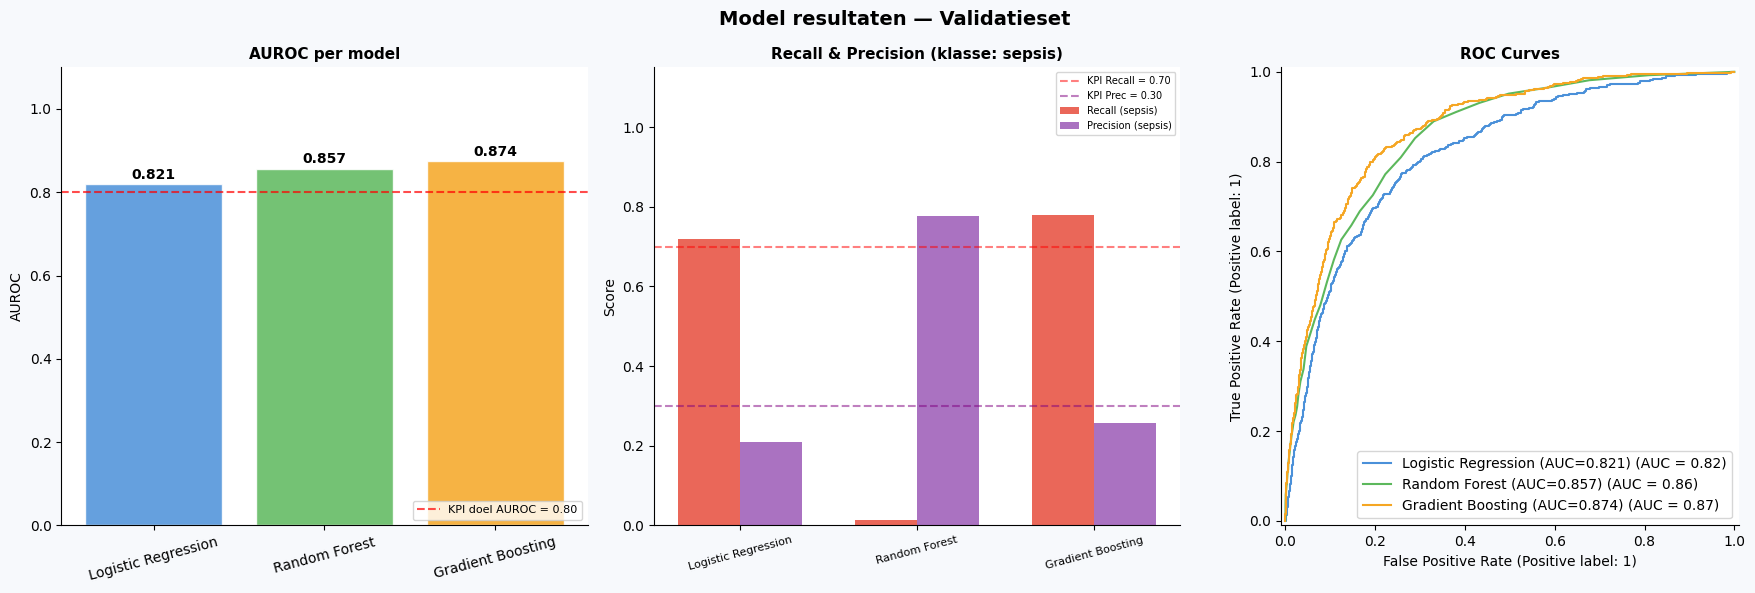

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#f7f9fc')
fig.suptitle('Model resultaten — Validatieset', fontsize=14, fontweight='bold')

# AUROC bars
ax = axes[0]
names  = list(results.keys())
aurocs = [results[n]['auroc'] for n in names]
ax.axhline(y=0.80, color='red', linestyle='--', alpha=0.7, label='KPI doel AUROC = 0.80')
bars = ax.bar(names, aurocs, color=['#4a90d9', '#5cb85c', '#f5a623'], edgecolor='white', alpha=0.85)
for bar, val in zip(bars, aurocs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_ylabel('AUROC')
ax.set_title('AUROC per model', fontsize=11, fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.tick_params(axis='x', rotation=15)
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

# Recall & Precision bars
ax = axes[1]
x = np.arange(len(names))
width = 0.35
recalls    = [results[n]['recall_1'] for n in names]
precisions = [results[n]['precision_1'] for n in names]
ax.bar(x - width/2, recalls, width, label='Recall (sepsis)', color='#e74c3c', alpha=0.85)
ax.bar(x + width/2, precisions, width, label='Precision (sepsis)', color='#9b59b6', alpha=0.85)
ax.axhline(y=0.70, color='red', linestyle='--', alpha=0.5, label='KPI Recall = 0.70')
ax.axhline(y=0.30, color='purple', linestyle='--', alpha=0.5, label='KPI Prec = 0.30')
ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, fontsize=8)
ax.set_ylabel('Score')
ax.set_title('Recall & Precision (klasse: sepsis)', fontsize=11, fontweight='bold')
ax.legend(fontsize=7, loc='upper right')
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

# ROC curves
ax = axes[2]
colors_roc = ['#4a90d9', '#5cb85c', '#f5a623']
for (name, probs), color in zip(val_probs.items(), colors_roc):
    RocCurveDisplay.from_predictions(y_val, probs, ax=ax, name=f'{name} (AUC={results[name]["auroc"]:.3f})',
                                     color=color)
ax.set_title('ROC Curves', fontsize=11, fontweight='bold')
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


**AUROC per model**\
Alle drie de modellen halen de KPI van 0.80. Gradient Boosting scoort het hoogst (0.874), gevolgd door Random Forest (0.857) en Logistic Regression (0.821). Op basis van AUROC alleen zou Random Forest of Gradient Boosting de voorkeur hebben.

**Recall & Precision**\
Hier ontstaat een duidelijk verschil tussen de modellen. Random Forest heeft een extreem lage recall (~0.01), wat dit betekent is dat het model bijna nooit sepsis voorspelt ondanks de class_weight correctie. Dit is geen goed teken voor dit model, aangezien recall een enorm belangrijke metric is voor dit onderzoek. Logistic Regression en Gradient Boosting halen beiden de KPI van 0.70 voor recall. Voor precision haalt geen enkel model de KPI van 0.30. Het model wat het dichts bij komt is Gradient Boosting met een precision van 0.26. Dit bevestigt het eerder genoemde probleem van alert fatigue.

**ROC Curves**\
De ROC-curve toont het trade-off tussen True Positive Rate (recall) en False Positive Rate bij verschillende drempelwaarden. Gradient Boosting heeft de grootste oppervlakte onder de curve en presteert daarmee het beste over alle drempelwaarden. Opvallend is dat alle drie de curves steil stijgen in het begin — het model heeft bij lage false positive rates al een redelijke detectie, wat gunstig is.

**Conclusie**\ 
Gradient Boosting is het beste model op zowel AUROC als recall, en komt het dichtst bij de precision-KPI. Random Forest valt af vanwege de vrijwel afwezige sepsisdetectie ondanks hoge AUROC — een klassiek voorbeeld van hoe AUROC alleen misleidend kan zijn bij klasse-onbalans.

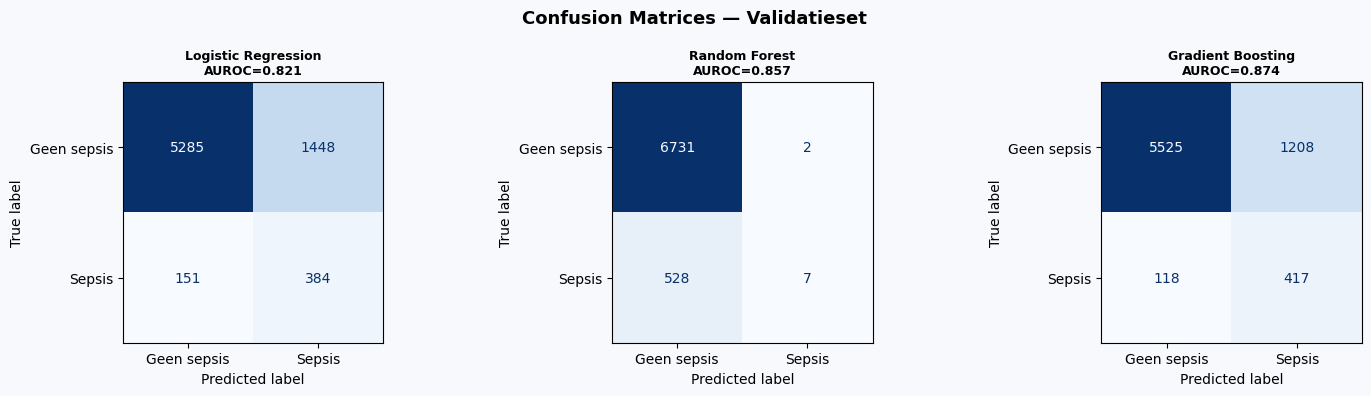


  Logistic Regression
              precision    recall  f1-score   support

 Geen sepsis       0.97      0.78      0.87      6733
      Sepsis       0.21      0.72      0.32       535

    accuracy                           0.78      7268
   macro avg       0.59      0.75      0.60      7268
weighted avg       0.92      0.78      0.83      7268


  Random Forest
              precision    recall  f1-score   support

 Geen sepsis       0.93      1.00      0.96      6733
      Sepsis       0.78      0.01      0.03       535

    accuracy                           0.93      7268
   macro avg       0.85      0.51      0.49      7268
weighted avg       0.92      0.93      0.89      7268


  Gradient Boosting
              precision    recall  f1-score   support

 Geen sepsis       0.98      0.82      0.89      6733
      Sepsis       0.26      0.78      0.39       535

    accuracy                           0.82      7268
   macro avg       0.62      0.80      0.64      7268
weighted avg 

In [49]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor='#f7f9fc')
fig.suptitle('Confusion Matrices — Validatieset', fontsize=13, fontweight='bold')

for ax, name in zip(axes, results.keys()):
    cm = confusion_matrix(y_val, results[name]['preds'])
    ConfusionMatrixDisplay(cm, display_labels=['Geen sepsis', 'Sepsis']).plot(
        ax=ax, cmap='Blues', colorbar=False
    )
    ax.set_title(f'{name}\nAUROC={results[name]["auroc"]:.3f}', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Classification reports
for name in results:
    print(f'\n{"="*60}\n  {name}\n{"="*60}')
    print(classification_report(y_val, results[name]['preds'],
                                 target_names=['Geen sepsis', 'Sepsis']))

**Logistic Regression:**
* **True Positive:** 384 — sepsisgevallen correct gedetecteerd
* **True Negative:** 5285 — geen-sepsispatiënten correct afgewezen
* **False Positive:** 1448 — geen-sepsispatiënten onterecht als sepsis geclassificeerd
* **False Negative:** 151 — sepsisgevallen gemist

**Beoordeling:**\ 
Redelijk model. 72% van de sepsisgevallen wordt gevonden, maar 1448 valse alarmen is hoog — bijna 1 op de 5 niet-sepsispatiënten krijgt onterecht een alarm. Bruikbaar als vroegwaarschuwing maar genereert veel onnodige werkdruk.
<br/><br>

**Random Forest:**
* **True Positive:** 7 — sepsisgevallen correct gedetecteerd
* **True Negative:** 6731 — geen-sepsispatiënten correct afgewezen
* **False Positive:** 2 — nauwelijks valse alarmen
* **False Negative:** 528 — sepsisgevallen gemist

**Beoordeling:**\ 
Onbruikbaar voor dit doel. Het model voorspelt vrijwel altijd geen sepsis — slechts 7 van de 535 sepsisgevallen worden gevonden. De hoge accuracy (93%) is volledig misleidend en het gevolg van de klasse-onbalans. In een klinische context zou dit model levens kosten.
<br/><br>

**Gradient Boosting:**
* **True Positive:** 417 — sepsisgevallen correct gedetecteerd
* **True Negative:** 5525 — geen-sepsispatiënten correct afgewezen
* **False Positive:** 1208 — geen-sepsispatiënten onterecht als sepsis geclassificeerd
* **False Negative:** 118 — sepsisgevallen gemist

**Beoordeling:**\ 
Het beste model van de drie. 78% van de sepsisgevallen wordt gevonden en het aantal gemiste gevallen (118) is het laagst. De 1208 valse alarmen zijn minder dan bij Logistic Regression. Nog steeds veel vals alarm, maar de balans tussen detectie en werkdruk is het meest acceptabel voor klinisch gebruik.

### Feature importance — Gradient Boosting

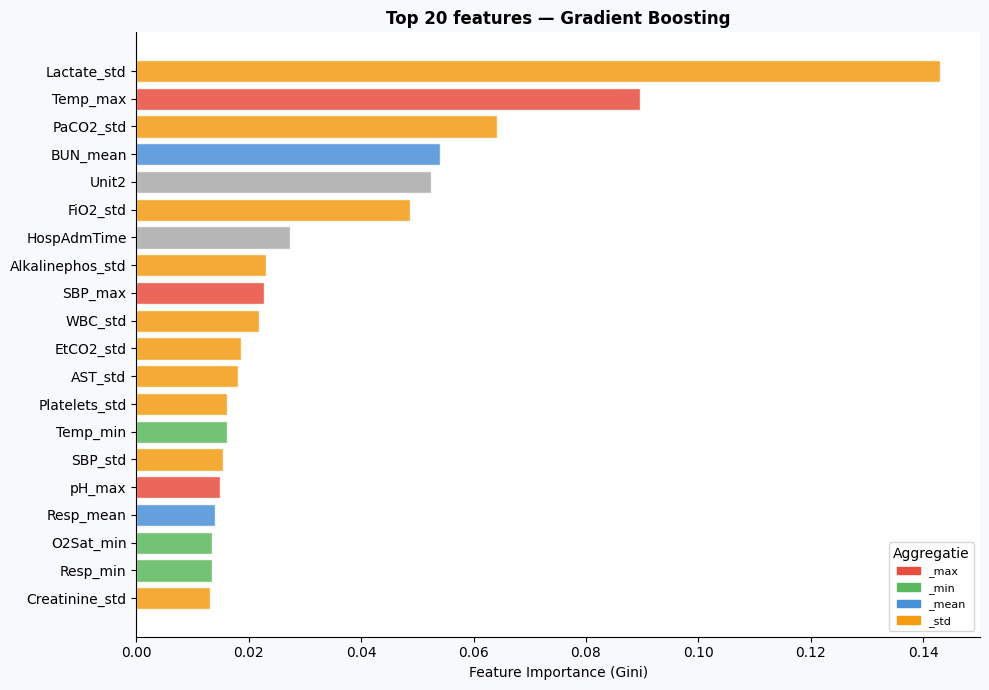

Top 10 features:
Lactate_std         0.1430
Temp_max            0.0896
PaCO2_std           0.0643
BUN_mean            0.0540
Unit2               0.0525
FiO2_std            0.0487
HospAdmTime         0.0274
Alkalinephos_std    0.0231
SBP_max             0.0228
WBC_std             0.0218
dtype: float64


In [50]:
rf_model = models['Gradient Boosting']
feat_imp = pd.Series(rf_model.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
top_n = 20

color_map = {'_max': '#e74c3c', '_min': '#5cb85c', '_mean': '#4a90d9', '_std': '#f39c12'}
colors_fi = []
for f in feat_imp.index[:top_n]:
    matched = '#aaaaaa'
    for suffix, color in color_map.items():
        if f.endswith(suffix):
            matched = color
            break
    colors_fi.append(matched)

fig, ax = plt.subplots(figsize=(10, 7), facecolor='#f7f9fc')
ax.barh(feat_imp.index[:top_n][::-1], feat_imp.values[:top_n][::-1],
        color=colors_fi[::-1], edgecolor='white', alpha=0.85)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title(f'Top {top_n} features — Gradient Boosting', fontsize=12, fontweight='bold')
legend_patches = [mpatches.Patch(color=c, label=s) for s, c in color_map.items()]
ax.legend(handles=legend_patches, title='Aggregatie', fontsize=8)
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(feat_imp.head(10).round(4))

**De belangrijkste feature is Lactate_std (0.14):** de fluctuatie in lactaatwaarden over het IC-verblijf is veruit het meest voorspellend. Dit is klinisch betekenisvol: niet de gemiddelde lactaatwaarde, maar de instabiliteit ervan signaleert sepsis. Een patiënt waarvan het lactaat sterk schommelt is fysiologisch instabiel, wat een vroeg sepsisteken kan zijn.

**Temp_max (0.09) staat op twee:** de hoogste gemeten temperatuur tijdens het verblijf is sterker voorspellend dan de gemiddelde temperatuur. Dit bevestigt wat eerder in de correlatie-analyse zichtbaar was: piekkoorts is informatiever dan gemiddelde koorts.

**Opvallend is dat _std features dominant zijn in de top 20:** 12 van de 20 features zijn standaarddeviaties. Dit bevestigt dat fysiologische instabiliteit over tijd een sterkere voorspeller is dan de gemiddelde toestand. Dit rechtvaardigt de keuze om std als aggregatie mee te nemen in de feature engineering.
Unit2 en HospAdmTime zijn demografische features zonder directe klinische waarde maar met voorspellend vermogen — ze vangen waarschijnlijk indirecte informatie over patiëntpopulaties of opnamepatronen.

**Individuele feature importance:** De individuele feature importance scores zijn over de hele linie laag, de meeste features scoren onder de 0.03. Dit sluit aan bij wat eerder in de correlatiematrices zichtbaar was: geen enkele feature heeft een sterke lineaire relatie met SepsisLabel. Toch behaalt het model een AUROC van 0.874, wat tegenstrijdig lijkt. De verklaring zit in hoe Gradient Boosting werkt: het model bouwt honderden beslissingsbomen sequentieel waarbij elke boom de fouten van de vorige corrigeert (anders dan Random Forest waar de beslisbomen onafhankelijk van elkaar worden gemaakt), waarbij elke boom kleine stukjes voorspellende informatie oppikt uit verschillende features. Geen enkele feature is op zichzelf sterk genoeg om sepsis betrouwbaar te voorspellen, maar de combinatie van 144 zwakke signalen samen levert wel een robuust voorspellend model op. Dit wordt ook wel het ensemble-effect genoemd: veel zwakke voorspellers samen vormen een sterke voorspeller.\
Dit verklaart ook waarom een simpel model zoals Logistic Regression minder goed presteert: dat model kan deze zwakke, niet-lineaire combinaties minder goed benutten dan een tree-based ensemble.

**Conclusie voor sepsis voorspelling:** het model leert dat verandering en instabiliteit betere signalen zijn dan absolute waarden. Dit sluit aan bij de klinische praktijk — een snel verslechterende patiënt is zorgwekkender dan een stabiel zieke patiëist.

### Fairness-analyse — geslacht & leeftijdsgroep

Als sub-doel wordt onderzocht of het beste model gelijk presteert voor verschillende patiëntgroepen. Een AUROC-verschil groter dan **0.05** tussen groepen wordt als een fairness-probleem beschouwd.

In [51]:
best_model_name = max(results, key=lambda n: results[n]['auroc'])
print(f'Beste model: {best_model_name}  (AUROC={results[best_model_name]["auroc"]:.3f})')

# Validatieset metadata ophalen via index
val_meta = df_pat_train.loc[X_val.index, ['Patient_ID', 'Age', 'Gender', 'leeftijdsgroep', 'Gender_label']].copy()
val_meta['pred_prob']  = val_probs[best_model_name]
val_meta['pred_label'] = results[best_model_name]['preds']
val_meta['true_label'] = y_val

# AUROC per geslacht
print('\n=== AUROC per geslacht ===')
fairness_gender = {}
for gender in ['Vrouw', 'Man']:
    sub = val_meta[val_meta['Gender_label'] == gender]
    if sub['true_label'].nunique() < 2: continue
    auc = roc_auc_score(sub['true_label'], sub['pred_prob'])
    rec = recall_score(sub['true_label'], sub['pred_label'])
    fairness_gender[gender] = {'AUROC': auc, 'Recall': rec, 'N': len(sub)}
    print(f'  {gender}: AUROC={auc:.3f}  Recall={rec:.3f}')

aucs_g = [v['AUROC'] for v in fairness_gender.values()]
diff_g = abs(aucs_g[0] - aucs_g[1]) if len(aucs_g) >= 2 else None
if diff_g is not None:
    print(f'  Verschil: {diff_g:.3f}  -> {"OK" if diff_g < 0.05 else "Fairness-probleem"}')

# AUROC per leeftijdsgroep
print('\n=== AUROC per leeftijdsgroep ===')
age_order = ['<45', '45-64', '65-74', '75+']
fairness_age = {}
for grp in age_order:
    sub = val_meta[val_meta['leeftijdsgroep'] == grp]
    if sub['true_label'].nunique() < 2: continue
    auc = roc_auc_score(sub['true_label'], sub['pred_prob'])
    rec = recall_score(sub['true_label'], sub['pred_label'])
    fairness_age[grp] = {'AUROC': auc, 'Recall': rec, 'N': len(sub)}
    print(f'  {grp}: AUROC={auc:.3f}  Recall={rec:.3f}')

aucs_a = [v['AUROC'] for v in fairness_age.values()]
diff_a = max(aucs_a) - min(aucs_a) if len(aucs_a) >= 2 else None
if diff_a is not None:
    print(f'  Max verschil: {diff_a:.3f}  -> {"Goed" if diff_a < 0.05 else "Fairness-probleem"}')

Beste model: Gradient Boosting  (AUROC=0.874)

=== AUROC per geslacht ===
  Vrouw: AUROC=0.871  Recall=0.756
  Man: AUROC=0.876  Recall=0.798
  Verschil: 0.005  -> OK

=== AUROC per leeftijdsgroep ===
  <45: AUROC=0.878  Recall=0.817
  45-64: AUROC=0.882  Recall=0.779
  65-74: AUROC=0.878  Recall=0.787
  75+: AUROC=0.854  Recall=0.750
  Max verschil: 0.027  -> Goed


**Geslacht:**\
Het model presteert vrijwel gelijk voor mannen en vrouwen: het AUROC-verschil is slechts 0.005, ruim onder de KPI-drempel van 0.05. De recall ligt voor mannen iets hoger (0.798 vs 0.756), wat betekent dat het model bij vrouwen iets meer sepsisgevallen mist. Het verschil is klein, maar wel relevant: 4.2 procentpunt minder recall betekent dat bij vrouwen relatief meer gevallen ongedetecteerd blijven.

**Leeftijdsgroep:**\
Ook over leeftijdsgroepen presteert het model consistent: het maximale AUROC-verschil is 0.027, onder de KPI-drempel van 0.05. Wel is er een licht dalend patroon zichtbaar in recall naarmate de leeftijd stijgt: de 75+ groep heeft de laagste recall (0.750) en de laagste AUROC (0.854). Oudere patiënten worden dus iets minder goed gedetecteerd, wat klinisch extra zorgelijk is omdat zij juist een hogere sterfte hebben bij sepsis.

**Conclusie:**\
Beide KPI's worden gehaald: het model vertoont geen ernstige fairness-problemen. Toch is er een consistent patroon: vrouwen en oudere patiënten scoren systematisch iets lager op recall. Dit sluit aan bij de eerder geconstateerde lichte ondervertegenwoordiging van vrouwen in de meetdata. Bij verdere ontwikkeling verdient dit aandacht.

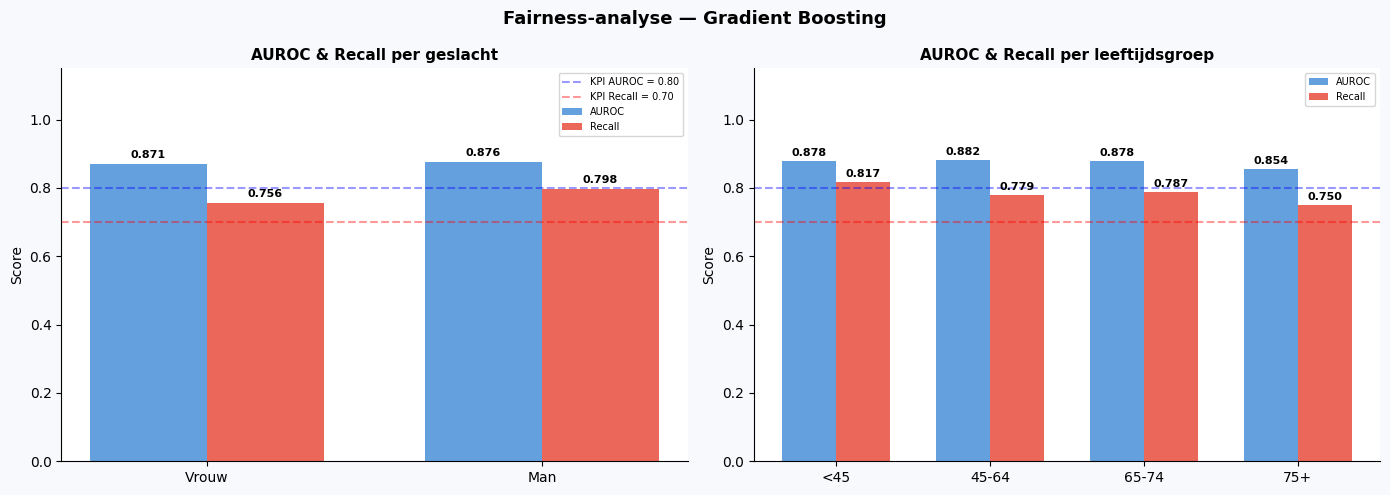


=== AUROC verschillen per subgroup ===
      Subgroup  Max AUROC  Min AUROC  Verschil
      Geslacht      0.876      0.871     0.005
Leeftijdsgroep      0.882      0.854     0.027


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#f7f9fc')
fig.suptitle(f'Fairness-analyse — {best_model_name}', fontsize=13, fontweight='bold')
width = 0.35

# Geslacht
ax = axes[0]
genders   = list(fairness_gender.keys())
aucs_plot = [fairness_gender[g]['AUROC'] for g in genders]
recs_plot = [fairness_gender[g]['Recall'] for g in genders]
x = np.arange(len(genders))
b1 = ax.bar(x - width/2, aucs_plot, width, label='AUROC',  color='#4a90d9', alpha=0.85)
b2 = ax.bar(x + width/2, recs_plot, width, label='Recall', color='#e74c3c', alpha=0.85)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.axhline(y=0.80, color='blue', linestyle='--', alpha=0.4, label='KPI AUROC = 0.80')
ax.axhline(y=0.70, color='red',  linestyle='--', alpha=0.4, label='KPI Recall = 0.70')
ax.set_xticks(x)
ax.set_xticklabels(genders)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('AUROC & Recall per geslacht', fontsize=11, fontweight='bold')
ax.legend(fontsize=7)
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

# Leeftijdsgroep
ax = axes[1]
grps        = [g for g in age_order if g in fairness_age]
aucs_a_plot = [fairness_age[g]['AUROC'] for g in grps]
recs_a_plot = [fairness_age[g]['Recall'] for g in grps]
x = np.arange(len(grps))
b1 = ax.bar(x - width/2, aucs_a_plot, width, label='AUROC',  color='#4a90d9', alpha=0.85)
b2 = ax.bar(x + width/2, recs_a_plot, width, label='Recall', color='#e74c3c', alpha=0.85)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.axhline(y=0.80, color='blue', linestyle='--', alpha=0.4)
ax.axhline(y=0.70, color='red',  linestyle='--', alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels(grps)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('AUROC & Recall per leeftijdsgroep', fontsize=11, fontweight='bold')
ax.legend(fontsize=7)
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

print('\n=== AUROC verschillen per subgroup ===')

differences = []

if len(aucs_g) >= 2:
    differences.append({'Subgroup': 'Geslacht', 'Max AUROC': max(aucs_g), 'Min AUROC': min(aucs_g), 'Verschil': max(aucs_g) - min(aucs_g)})

if len(aucs_a) >= 2:
    differences.append({'Subgroup': 'Leeftijdsgroep', 'Max AUROC': max(aucs_a), 'Min AUROC': min(aucs_a), 'Verschil': max(aucs_a) - min(aucs_a)})

df_diff = pd.DataFrame(differences)
print(df_diff.to_string(index=False, float_format='{:.3f}'.format))

De grafieken visualiseert de fairness-analyse uit de vorige code — beide KPI-lijnen (AUROC = 0.80 en Recall = 0.70) zijn zichtbaar als referentie.

**Geslacht:**\
Zowel AUROC als recall liggen voor beide geslachten boven de KPI-drempels. Het AUROC-verschil tussen man en vrouw is 0.005. De recall voor vrouwen (0.756) ligt net boven de KPI van 0.70, voor mannen iets hoger (0.798). Het model presteert dus bijna gelijk voor beide geslachten, al is er een kleine systematische achterstand voor vrouwen.

**Leeftijdsgroep:**\
Alle vier de leeftijdsgroepen halen beide KPI's. AUROC is consistent hoog over alle groepen (0.854–0.882) met een maximaal verschil van 0.027. De recall daalt licht met stijgende leeftijd: van 0.817 bij de jongste groep naar 0.750 bij 75+. De 75+ groep zit het dichtst bij de KPI-grens van 0.70, wat aandacht verdient bij verdere ontwikkeling.

**Conclusie:**\
Beide fairness-KPI's worden gehaald: geslacht (verschil 0.005) en leeftijdsgroep (verschil 0.027) zitten ruim onder de drempel van 0.05. Het model is daarmee voldoende eerlijk over demografische groepen. Het licht dalende patroon in recall bij oudere patiënten en vrouwen is een aandachtspunt, maar geen dealbreaker voor de huidige proof-of-concept fase.

### KPI-overzicht

In [53]:
best = results[best_model_name]

kpi_results = [
    ('AUROC >= 0.80',              best['auroc']       >= 0.80, f"{best['auroc']:.3f}"),
    ('Recall (sepsis) >= 0.70',    best['recall_1']    >= 0.70, f"{best['recall_1']:.3f}"),
    ('Precision (sepsis) >= 0.30', best['precision_1'] >= 0.30, f"{best['precision_1']:.3f}"),
]
if diff_g is not None:
    kpi_results.append(('AUROC-verschil geslacht < 0.05', diff_g < 0.05, f'{diff_g:.3f}'))
if diff_a is not None:
    kpi_results.append(('AUROC-verschil leeftijd < 0.05', diff_a < 0.05, f'{diff_a:.3f}'))

print(f'=== KPI-overzicht - {best_model_name} ===')
print(f'{"KPI":40s} {"Waarde":>10}  Status')
print('-' * 65)
for kpi, behaald, waarde in kpi_results:
    status = 'Behaald' if behaald else 'Niet behaald'
    print(f'{kpi:40s} {waarde:>10}  {status}')

=== KPI-overzicht - Gradient Boosting ===
KPI                                          Waarde  Status
-----------------------------------------------------------------
AUROC >= 0.80                                 0.874  Behaald
Recall (sepsis) >= 0.70                       0.779  Behaald
Precision (sepsis) >= 0.30                    0.257  Niet behaald
AUROC-verschil geslacht < 0.05                0.005  Behaald
AUROC-verschil leeftijd < 0.05                0.027  Behaald


---

## **MC1 - Data mining**

### Samenvatting CRISP-DM proces

| Fase | Aanpak & Bevinding |
|---|---|
| **Business Understanding** | Vroegtijdige sepsissignalering op de IC van het Isala ziekenhuis; fairness als sub-doel |
| **Data Understanding** | 1,4M observaties, 36K patienten, 1,82% sepsis; tijdreeksanalyse toont vroege afwijkingen in HR, Resp en Lactate |
| **Data Preparation** | Aggregatie per patient (mean/min/max/std), mediaan-imputation, StandardScaler, stratified split 80/20 |
| **Modeling** | Logistic Regression, Random Forest, Gradient Boosting met class_weight='balanced' |
| **Evaluation** | AUROC, recall, precision, F1-macro & fairness per geslacht en leeftijdsgroep, feature importance |
| **Deployment** | Voorspellingen op testset, aanbevelingen voor EPD-integratie en drempelkalibratie |

---

## **AD1 - Evaluation**

#### **Keuze metrics**
Er is voor dit onderzoek gekozen om te kijken naar een aantal metrics. Deze zijn AUROC, Recall, Precision en F1-macro. Waarom deze gekozen zijn wordt hier onder uitgeled:
* **AUROC:** Meet hoe goed het model sepsispatiënten een hogere risicoscore geeft dan niet-sepsispatiënten, onafhankelijk van een drempelwaarde. Robuust bij klasse-onbalans omdat het de volledige rankingprestatie samenvat.
* **Recall:** Meet hoeveel sepsisgevallen het model daadwerkelijk detecteert. Kritiekste metric in deze context — een gemiste sepsis (false negative) kan fatale gevolgen hebben.
* **Precision:** Meet hoeveel van de sepsisalarmen terecht zijn. Belangrijk om alarm-moeheid bij IC-personeel te voorkomen — te veel valse alarmen verlagen de werkdruk en geloofwaardigheid van het systeem.
* **F1-macro:** Harmonisch gemiddelde van precision en recall, berekend per klasse en dan gemiddeld. Geeft een gebalanceerd beeld van de prestaties over beide klassen, wat bij klasse-onbalans eerlijker is dan accuracy.

#### **Bruikbaarheid modellen / modelresultaten**
* Logistische regressie  (AUROC = 0.821 | Recall = 0.718 | Precision = 0.210 | Macro F1 score = 0.597)
* Random Forest          (AUROC = 0.857 | Recall = 0.013 | Precision = 0.778 | Macro F1 score = 0.494)
* Gradient Boosting      (AUROC = 0.874 | Recall = 0.779 | Precision = 0.257 | Macro F1 score = 0.639)

De resultaten zien er belovend uit. De AUROC is voor alle drie de modellen boven 0.8. Wat tegenvalt is precision. De modellen scoren hier vrij laag op, behalve Random Forest, maar dit model scoort dan weer laag op recall. Het beste model is Gradient Boosting. Deze scoort op drie van de vier metrics het beste.

#### **Verklaring resultaten**
De hoge AUROC-scores (0.821–0.874) zijn te verklaren door de aggregatiestrategie: door per patiënt de mean, min, max en std te berekenen worden patronen zichtbaar die op uurobservatie-niveau verborgen blijven. De combinatie van ~130 features stelt Gradient Boosting in staat niet-lineaire verbanden te leren die individuele correlaties (maximaal 0.28) niet weerspiegelen.
De lage precision is deels inherent aan de klasse-onbalans van 6.6% sepsispatiënten. Het gebruik van `class_weight='balanced'` drijft recall omhoog maar produceert tegelijkertijd meer valse alarmen — een bewuste afweging waarbij een gemiste sepsis zwaarder weegt dan een vals alarm.

#### **Belangrijke Features**
De modellen hebben inzicht gegeven in welke eye tracking data de meeste correlatie hebben met de gegeven rating. In dit geval is het Lactate_std.

#### **Beste model**
Zoals al eerder vastgesteld is het beste model Gradient Boosting. Op basis van dit model bekijken we of de KPI's zijn behaald. 

#### **Vergelijking KPI's**
KPI's:
* Top 3 invloedrijke kenmerken bepalen ✓ Behaald
* Een **AUROC ≥ 0.80** behalen ✓ Behaald
* Een **recall ≥ 0.70** voor de klasse `SepsisLabel = 1` ✓ Behaald
* **Precision ≥ 0.30** voor de klasse `SepsisLabel = 1` ✕ Niet behaald 
* Het verschil in AUROC tussen geslachten en leeftijdsgroepen kleiner dan **0.05** ✓ Behaaldd


Resultaat:
* De top 3 meest invloedrijke oog eigenschappen kunnen door middel van het gemaakte model Random Forest bepaald worden:
    * Lactate_std
    * Temp_max
    * PaCO2_std
* De AUROC score van Gradient Boosting is 0.874
* De recall voor `SepsisLabel = 1` is 0.778
* Precision voor `SepsisLabel = 1` is 0.257
* Geslacht verschil zit op 0.005, wat ver onder de drempel van 0.05 ligt. Voor de leeftijdsgroepen is het verschil iets groter, maar deze ligt nog steeds onder de drempel — 0.027.

#### **Stakeholders**
Bij sepsis is een gemiste diagnose veel erger dan een vals alarm — sepsis kan binnen uren dodelijk zijn. Dus hoge recall heeft prioriteit boven precision.\
Gradient Boosting past daar het beste bij, maar 74% vals alarm betekent wel dat verpleegkundigen veel onnodige checks doen → alert fatigue is een reëel risico.\
Praktische conclusie voor stakeholders: het model kan dienen als vroeg waarschuwingssysteem ter ondersteuning, niet als vervanging van klinisch oordeel. Elke alert moet nog beoordeeld worden door een zorgverlener.

#### **Maatschappelijke implicaties**
* **Patiëntveiligheid:** Gradient Boosting detecteert 78% van de echte sepsisgevallen. Dit betekent dat 22% van de patiënten met sepsis niet gesignaleerd wordt — in een IC-context een ernstig risico gezien de hoge mortaliteit van sepsis. Het model is daarmee nog niet veilig genoeg voor zelfstandige klinische inzet, maar kan wel als aanvullend vroegwaarschuwingssysteem dienen naast bestaande protocollen.
**Werkdruk zorgpersoneel:** Precision van 0.26 betekent dat 74% van de alarmen vals is. Voor IC-personeel dat al onder hoge werkdruk staat, leidt dit tot alert fatigue — een bekend fenomeen waarbij zorgverleners alarmen gaan negeren of minder serieus nemen. Het model verlaagt de werkdruk dus niet per se; het risico bestaat dat het die juist verhoogt door een constante stroom ongegronde meldingen.
**Fairness:** Dit is het expliciete sub-doel van het onderzoek. Als het model al overall 22% van de sepsisgevallen mist, is het cruciaal te weten of die missers gelijkmatig verdeeld zijn over leeftijdsgroepen en geslachten. Als het model bijvoorbeeld structureel slechter presteert bij vrouwen of oudere patiënten, reproduceert het bestaande zorgongelijkheid. De fairness-analyse moet dit aantonen of weerleggen.
**Privacy:** De dataset is geanonimiseerd, wat het risico op privacyschending beperkt. In een echte ziekenhuisomgeving geldt AVG Artikel 9 — medische gegevens zijn bijzondere persoonsgegevens. De huidige resultaten zijn nog onvoldoende voor productie-inzet, maar bij verdere ontwikkeling vereist verwerking van real-time patiëntdata een expliciete juridische grondslag en verwerkersovereenkomsten.
**Automation bias:** Met een F1-macro van 0.639 is het model verre van onfeilbaar. Toch bestaat het risico dat zorgverleners de modeluitkomst als leidend gaan zien, zeker als het systeem zelfverzekerd een score presenteert zonder onzekerheidsinterval. Bij de 22% gemiste sepsisgevallen is het gevaar dat een verpleegkundige een klinisch vermoeden negeert omdat "het model zegt dat het goed gaat."
**Klasse-onbalans:** Random Forest illustreert dit probleem perfect: 93% accuracy terwijl het model bijna nooit sepsis detecteert. Dit bevestigt waarom accuracy een misleidende metric is bij deze dataverdeling en macro F1 de juiste keuze is als primaire evaluatiemetric. Voor stakeholders is het belangrijk dit expliciet toe te lichten — anders lijkt Random Forest het beste model op het eerste gezicht.
* **Invloed op detectie:** Gradient Boosting mist 22% van de echte sepsisgevallen en geeft bij 74% van de alarmen een vals signaal. Als zorgverleners gewend raken aan het systeem en hier te veel op vertrouwen, kunnen deze fouten directe gevolgen hebben: een gemiste sepsis omdat het model geen alarm gaf, of een arts die een klinisch vermoeden negeert omdat de modeluitkomst geruststellend is. De eindverantwoordelijkheid voor de diagnose moet daarom altijd bij de behandelend arts liggen — het model is in de huidige staat niet betrouwbaar genoeg om als leidend te beschouwen.

#### **Advies**
Het model wordt niet aanbevolen voor zelfstandige klinische inzet in de huidige staat. Gradient Boosting, het beste model, mist 22% van de sepsisgevallen — in een IC-context onaanvaardbaar gezien de hoge mortaliteit. Daarnaast zorgt de lage precision (0.26) voor een hoge mate van vals alarm, wat alert fatigue in de hand werkt.
Het model kan wel dienen als aanvullend vroegwaarschuwingssysteem, mits het klinisch oordeel van de behandelend arts altijd leidend blijft en de beperkingen expliciet gecommuniceerd worden aan zorgverleners. Verdere ontwikkeling — met name het verbeteren van precision zonder recall significant te verlagen — is noodzakelijk voordat serieuze inzet overwogen kan worden.\
Verder is het advies om onderstaande vervolgstappen te volgen.

#### **Vervolgstappen**
Als verder onderzoek gedaan wordt naar de beoordeling van piloten op basis van fysiologische data kunnen de volgende stappen gezet worden:
1. **Verbeteren van precision:** Het huidige model geeft te veel valse alarmen. Vervolgonderzoek kan zich richten op het optimaliseren van de beslissingsdrempel (threshold tuning) om een betere balans tussen recall en precision te vinden, afhankelijk van de klinische tolerantie voor vals alarm.
2. **Uitbreiden van de dataset:** De huidige dataset bevat ~36K patiënten. Een groter en diverser cohort — bijvoorbeeld uit meerdere ziekenhuizen of landen — kan de generaliseerbaarheid van het model verbeteren en de fairness-analyse robuuster maken.
3. Fairness-analyse verdiepen: De huidige analyse kijkt naar leeftijd en geslacht. Vervolgonderzoek kan aanvullende demografische factoren meenemen, zoals etniciteit of comorbiditeiten, om ongelijke prestaties verder in kaart te brengen.
3. **Aanpakken van klasse-onbalans:** De dataset bevat slechts ~1.8% sepsislabels. Technieken zoals SMOTE (oversampling van de minderheidsklasse), undersampling van de meerderheidsklasse, of het meegeven van class weights aan het model kunnen helpen om de prestaties op de sepsisklasse te verbeteren zonder de algehele modelkwaliteit te verlagen. Dit is een logische eerste stap voordat complexere architecturen worden overwogen.

#### **Antwoord op de businessvraag**
> Kunnen we op basis van klinische meetwaarden (vitale parameters, laboratoriumwaarden en demografische data) vroegtijdig voorspellen of een IC-patiënt sepsis zal ontwikkelen?

Door vitale parameters en laboratoriumwaarden te aggregeren per patient (mean, min, max, std) en drie classificatiemodellen te vergelijken, is aangetoond dat machine learning beter dan kansniveau presteert in het voorspellen van sepsis.

#### **Morele vraag**

**Situatie:** Voorspellend model (getraind op traindata van Isala) dat beoordeelt of een patient sepsis heeft (0 = geen sepsis | 1 = sepsis).

**Morele vraag:** Is het ethisch verantwoord om een voorspelend model in te zetten voor sepsissignalering op de IC, wetende dat het model fouten maakt en dat die fouten levensbedreigende gevolgen kunnen hebben voor patienten?

**Botsende waarden**
* **Patientveiligheid vs. alarm-moeheid:** Een hoge recall vermindert gemiste sepsisgevallen maar verhoogt valse alarmen. Te veel alarmen leiden tot alarm-moeheid bij IC-personeel, waardoor echte alarmen worden genegeerd.
* **Gelijkheid (fairness):** Als het model slechter presteert voor vrouwen of oudere patienten, leidt dit tot ongelijke zorgkwaliteit.
* **Autonomie van zorgverleners:** Automation bias is een reeel risico: verpleegkundigen en artsen kunnen het model klakkeloos volgen zonder klinische redenering.
* **Privacy:** Medische gegevens zijn bijzondere persoonsgegevens (AVG Art. 9). In productie is expliciete juridische grondslag vereist.

**Gevolgenethiek:** Eerder behandelen = hogere overlevingskansen. Dit rechtvaardigt inzet, mits recall hoog genoeg is en fairness gewaarborgd is.

**Plichtethiek:** Transparantieplicht — zorgverleners moeten begrijpen waarop het model baseert. De feature importance grafiek draagt hieraan bij.

**Deugdethiek:** Eerlijk rapporteren over modellimieten, ook als resultaten tegenvallen.

**Moreel oordeel:** 
Het model mag worden ingezet als **hulpmiddel** als:
1. Recall voor sepsis >= 0.70
2. AUROC-verschil tussen subgroepen < 0.05
3. Het model wordt aangeboden als *decision support*, niet als zelfstandige diagnose
4. Menselijk toezicht gegarandeerd is en zorgverleners training ontvangen over de limieten